In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

In [2]:
cal = pd.read_csv("layers_vit_base_patch16_clip_quickgelu_224_metaclip_400m_Imagenet.csv")
test = pd.read_csv("layers_vit_base_patch16_clip_quickgelu_224_metaclip_400m_ForenSynths.csv")

TEST AUROC: 0.5771   (1 - AUROC = 0.4229)
TEST AP:    0.6411

Cal real median: 3331.29
Test real median: 3313.94
Test fake median: 3391.16

Threshold @ 99th pct of cal reals: 4040.43
Test accuracy at that threshold:   0.4740


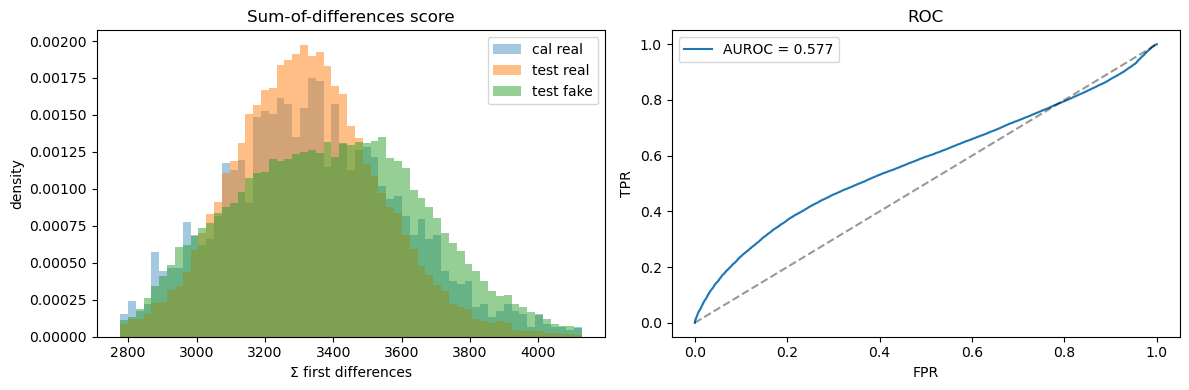

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

# Sum-of-differences score per image.
# Note: sum(diff(x)) telescopes to x[-1] - x[0], so this is equivalent
# to (last layer score) - (first kept layer score) — a single trajectory span.
test_scores = np.diff(test_raw, n=1, axis=1).sum(axis=1)   # [N_test]
cal_scores  = np.diff(cal_raw_real, n=1, axis=1).sum(axis=1)

test_labels = test_df["label"].to_numpy()

# AUROC / AP — try both directions since the sign isn't known a priori
auroc = roc_auc_score(test_labels, test_scores)
ap    = average_precision_score(test_labels, test_scores)
print(f"TEST AUROC: {auroc:.4f}   (1 - AUROC = {1 - auroc:.4f})")
print(f"TEST AP:    {ap:.4f}")

# Quick group medians for sanity
print(f"\nCal real median: {np.median(cal_scores):.2f}")
print(f"Test real median: {np.median(test_scores[test_labels == 0]):.2f}")
print(f"Test fake median: {np.median(test_scores[test_labels == 1]):.2f}")

# Threshold from cal reals only — pick the side that makes 'higher = more anomalous'
# Detect direction from cal vs test_fake medians; default: higher score = fake
fake_higher = np.median(test_scores[test_labels == 1]) > np.median(cal_scores)
if fake_higher:
    score_signed = test_scores
    threshold    = np.quantile(cal_scores, 0.99)
    pred         = score_signed > threshold
else:
    score_signed = -test_scores
    threshold    = np.quantile(-cal_scores, 0.99)
    pred         = score_signed > threshold
acc = (pred == test_labels).mean()
print(f"\nThreshold @ 99th pct of cal reals: {threshold:.2f}")
print(f"Test accuracy at that threshold:   {acc:.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
real_s = test_scores[test_labels == 0]
fake_s = test_scores[test_labels == 1]
lo, hi = np.quantile(test_scores, [0.005, 0.995])
bins = np.linspace(lo, hi, 60)
ax.hist(cal_scores, bins=bins, alpha=0.4, density=True, label="cal real")
ax.hist(real_s,     bins=bins, alpha=0.5, density=True, label="test real")
ax.hist(fake_s,     bins=bins, alpha=0.5, density=True, label="test fake")
ax.set_xlabel("Σ first differences"); ax.set_ylabel("density")
ax.set_title("Sum-of-differences score"); ax.legend()

ax = axes[1]
fpr, tpr, _ = roc_curve(test_labels, test_scores)
ax.plot(fpr, tpr, label=f"AUROC = {auroc:.3f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC"); ax.legend()

plt.tight_layout(); plt.show()

TEST AUROC: 0.4927   (1 - AUROC = 0.5073)
TEST AP:    0.5461

Cal real median:  3691.28
Test real median: 3673.04
Test fake median: 3672.58

Threshold @ 99th pct of cal reals: 4408.68
Test accuracy at that threshold:   0.4691


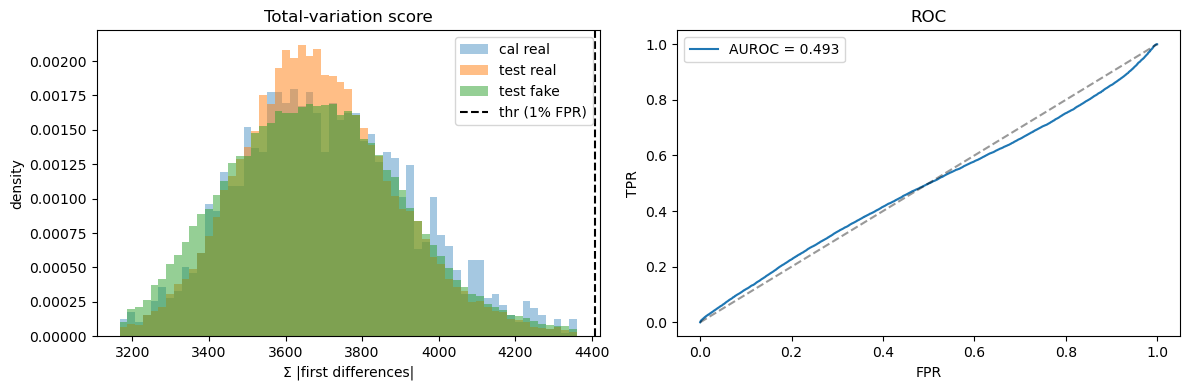

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

# Sum of absolute first differences — total variation of the trajectory.
# Unlike sum(diff), this does NOT telescope: it uses every layer transition
# and captures spikiness regardless of direction.
test_scores = np.abs(np.diff(test_raw,     n=1, axis=1)).sum(axis=1)   # [N_test]
cal_scores  = np.abs(np.diff(cal_raw_real, n=1, axis=1)).sum(axis=1)   # [N_cal]

test_labels = test_df["label"].to_numpy()

auroc = roc_auc_score(test_labels, test_scores)
ap    = average_precision_score(test_labels, test_scores)
print(f"TEST AUROC: {auroc:.4f}   (1 - AUROC = {1 - auroc:.4f})")
print(f"TEST AP:    {ap:.4f}")

print(f"\nCal real median:  {np.median(cal_scores):.2f}")
print(f"Test real median: {np.median(test_scores[test_labels == 0]):.2f}")
print(f"Test fake median: {np.median(test_scores[test_labels == 1]):.2f}")

# Threshold from cal reals only (1% FPR), assuming higher = more anomalous
threshold = np.quantile(cal_scores, 0.99)
acc = ((test_scores > threshold) == test_labels).mean()
print(f"\nThreshold @ 99th pct of cal reals: {threshold:.2f}")
print(f"Test accuracy at that threshold:   {acc:.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
real_s = test_scores[test_labels == 0]
fake_s = test_scores[test_labels == 1]
lo, hi = np.quantile(np.concatenate([cal_scores, test_scores]), [0.005, 0.995])
bins = np.linspace(lo, hi, 60)
ax.hist(cal_scores, bins=bins, alpha=0.4, density=True, label="cal real")
ax.hist(real_s,     bins=bins, alpha=0.5, density=True, label="test real")
ax.hist(fake_s,     bins=bins, alpha=0.5, density=True, label="test fake")
ax.axvline(threshold, color="k", linestyle="--", label="thr (1% FPR)")
ax.set_xlabel("Σ |first differences|"); ax.set_ylabel("density")
ax.set_title("Total-variation score"); ax.legend()

ax = axes[1]
fpr, tpr, _ = roc_curve(test_labels, test_scores)
ax.plot(fpr, tpr, label=f"AUROC = {auroc:.3f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC"); ax.legend()

plt.tight_layout(); plt.show()

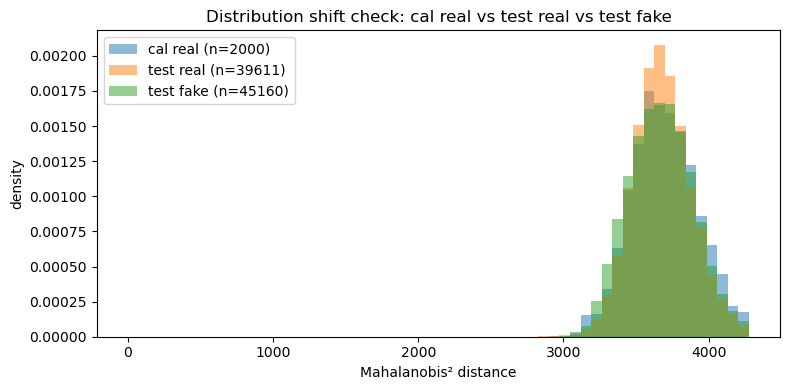

KS(cal real,  test real):  stat=0.070, p=1.13e-08
KS(test real, test fake):  stat=0.051, p=5.35e-48
→ if KS(cal,test_real) is large, calibration is the problem, not the aggregator.

Per-layer summary (mean ± std):
            cal_real_mean  test_real_mean  test_fake_mean  cal_real_std  \
layer_1          -3671.42        -3582.74        -3406.77        254.14   
layer_2          -2917.09        -2766.12        -2642.69        259.94   
layer_3          -2375.73        -2234.90        -2129.35        238.73   
layer_4          -1561.65        -1404.43        -1314.82        247.03   
layer_5           -996.41         -844.08         -763.42        247.65   
layer_6           -761.22         -630.83         -544.79        243.13   
layer_7           -573.15         -461.98         -349.95        264.38   
layer_8           -384.03         -295.24         -113.94        262.83   
layer_9           -432.94         -338.71         -121.60        275.43   
layer_10          -247.93         -1

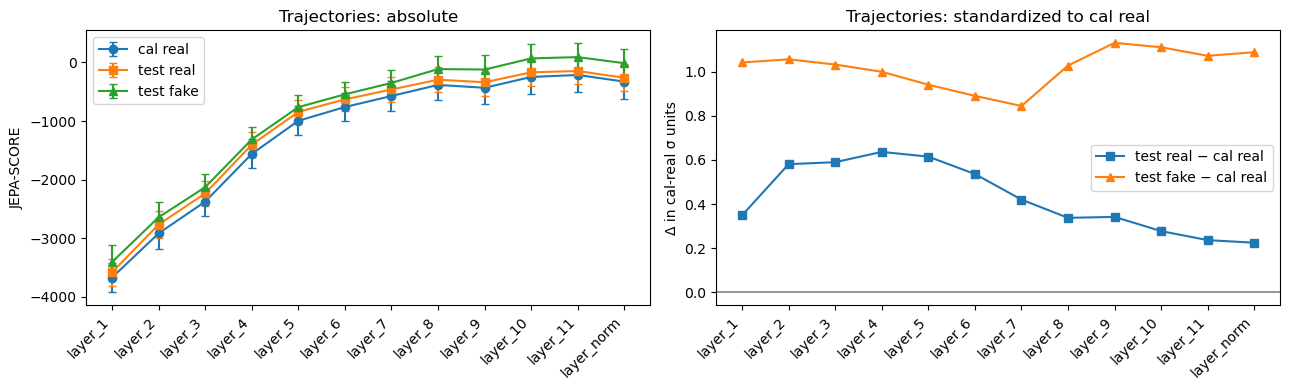

→ if the two lines on the right plot are similar, layers don't separate real/fake.
→ if test_real line is far from 0, you have calibration-vs-test shift in the reals themselves.

Single-layer AUROC on test set (using just one column as the score):
(score = layer value; we also report 1-AUROC since the sign isn't known a priori)
       layer_1: AUROC=0.680   (max(AUROC, 1-AUROC)=0.680)
       layer_2: AUROC=0.643   (max(AUROC, 1-AUROC)=0.643)
       layer_3: AUROC=0.645   (max(AUROC, 1-AUROC)=0.645)
       layer_4: AUROC=0.634   (max(AUROC, 1-AUROC)=0.634)
       layer_5: AUROC=0.622   (max(AUROC, 1-AUROC)=0.622)
       layer_6: AUROC=0.633   (max(AUROC, 1-AUROC)=0.633)
       layer_7: AUROC=0.659   (max(AUROC, 1-AUROC)=0.659)
       layer_8: AUROC=0.728   (max(AUROC, 1-AUROC)=0.728)
       layer_9: AUROC=0.750   (max(AUROC, 1-AUROC)=0.750)
      layer_10: AUROC=0.772   (max(AUROC, 1-AUROC)=0.772)
      layer_11: AUROC=0.778   (max(AUROC, 1-AUROC)=0.778)
    layer_norm: AUROC=0.778   (m

/tmp/ipykernel_31516/2574163603.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(layer_cols, rotation=45, ha="right")


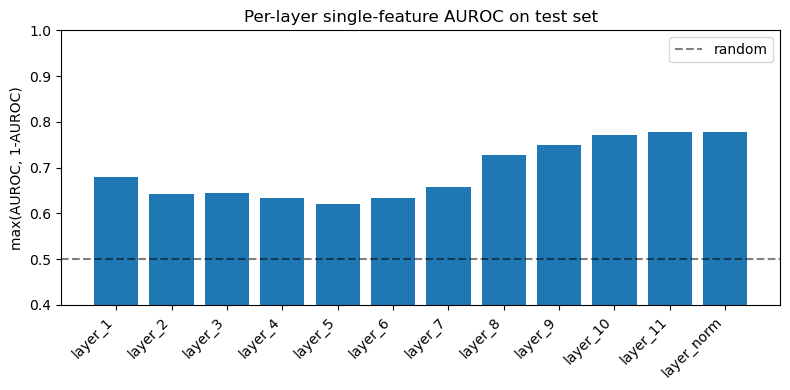


Best single layer: layer_norm  (AUROC*=0.778)
→ if best single layer is well above 0.5, signal exists — Mahalanobis is washing it out.
→ if no single layer beats ~0.55, the JEPA-SCORE itself is the problem on this test set.
⚠ Looking at single-layer AUROCs uses test labels. Use this purely for diagnosis,
   not for picking the layer to report — that would break zero-shot.

Single-difference AUROC on test set:
                 layer_1→layer_2: AUROC=0.360   (max=0.640)
                 layer_2→layer_3: AUROC=0.423   (max=0.577)
                 layer_3→layer_4: AUROC=0.428   (max=0.572)
                 layer_4→layer_5: AUROC=0.427   (max=0.573)
                 layer_5→layer_6: AUROC=0.535   (max=0.535)
                 layer_6→layer_7: AUROC=0.692   (max=0.692)
                 layer_7→layer_8: AUROC=0.802   (max=0.802)
                 layer_8→layer_9: AUROC=0.703   (max=0.703)
                layer_9→layer_10: AUROC=0.601   (max=0.601)
               layer_10→layer_11: AUROC=0.502 

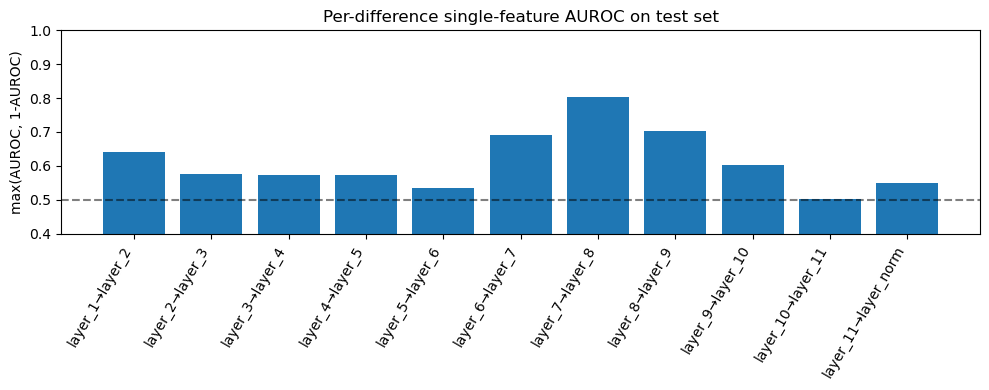


Per-layer KS distance, cal real vs test real (large values = calibration shift in that layer):
       layer_1: KS=0.185, p=3.30e-57
       layer_2: KS=0.248, p=2.86e-103
       layer_3: KS=0.239, p=1.83e-96
       layer_4: KS=0.272, p=1.32e-124
       layer_5: KS=0.270, p=1.81e-123
       layer_6: KS=0.241, p=3.74e-98
       layer_7: KS=0.212, p=3.02e-75
       layer_8: KS=0.160, p=8.63e-43
       layer_9: KS=0.156, p=1.05e-40
      layer_10: KS=0.147, p=3.78e-36
      layer_11: KS=0.139, p=1.35e-32
    layer_norm: KS=0.126, p=8.73e-27


/tmp/ipykernel_31516/2574163603.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(layer_cols, rotation=45, ha="right")


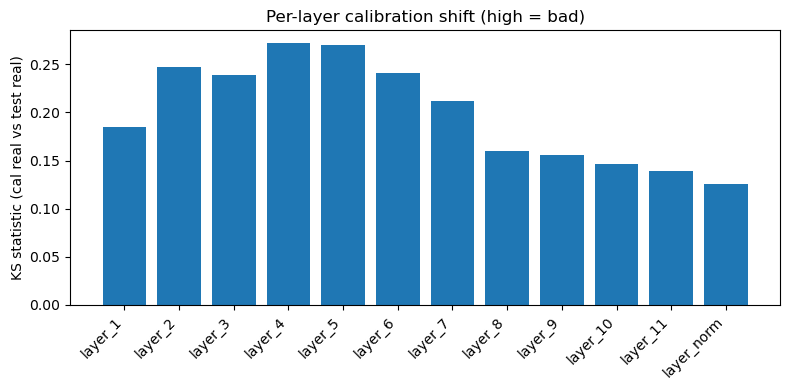

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------------------------------
# 1. Calibration-vs-test distribution shift
#    Are cal reals and test reals from the same distribution?
# ---------------------------------------------------------------------------
test_real_scores = test_scores[test_labels == 0]
test_fake_scores = test_scores[test_labels == 1]

upper = np.quantile(np.concatenate([cal_scores, test_scores]), 0.99)
bins = np.linspace(0, upper, 60)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(cal_scores,       bins=bins, alpha=0.5, density=True, label=f"cal real (n={len(cal_scores)})")
ax.hist(test_real_scores, bins=bins, alpha=0.5, density=True, label=f"test real (n={len(test_real_scores)})")
ax.hist(test_fake_scores, bins=bins, alpha=0.5, density=True, label=f"test fake (n={len(test_fake_scores)})")
ax.set_xlabel("Mahalanobis² distance"); ax.set_ylabel("density")
ax.set_title("Distribution shift check: cal real vs test real vs test fake")
ax.legend()
plt.tight_layout(); plt.show()

# Quantitative shift: KS statistic between cal real and test real
from scipy.stats import ks_2samp
ks_cal_vs_treal = ks_2samp(cal_scores, test_real_scores)
ks_treal_vs_tfake = ks_2samp(test_real_scores, test_fake_scores)
print(f"KS(cal real,  test real):  stat={ks_cal_vs_treal.statistic:.3f}, p={ks_cal_vs_treal.pvalue:.2e}")
print(f"KS(test real, test fake):  stat={ks_treal_vs_tfake.statistic:.3f}, p={ks_treal_vs_tfake.pvalue:.2e}")
print("→ if KS(cal,test_real) is large, calibration is the problem, not the aggregator.")

# ---------------------------------------------------------------------------
# 2. Per-layer means: where does the trajectory differ across groups?
# ---------------------------------------------------------------------------
test_real_raw = test_raw[test_labels == 0]
test_fake_raw = test_raw[test_labels == 1]

summary = pd.DataFrame({
    "cal_real_mean":  cal_raw_real.mean(axis=0),
    "test_real_mean": test_real_raw.mean(axis=0),
    "test_fake_mean": test_fake_raw.mean(axis=0),
    "cal_real_std":   cal_raw_real.std(axis=0),
    "test_real_std":  test_real_raw.std(axis=0),
    "test_fake_std":  test_fake_raw.std(axis=0),
}, index=layer_cols)
print("\nPer-layer summary (mean ± std):")
print(summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) absolute trajectories
ax = axes[0]
x = np.arange(len(layer_cols))
ax.errorbar(x, summary["cal_real_mean"],  yerr=summary["cal_real_std"],  label="cal real",  marker="o", capsize=3)
ax.errorbar(x, summary["test_real_mean"], yerr=summary["test_real_std"], label="test real", marker="s", capsize=3)
ax.errorbar(x, summary["test_fake_mean"], yerr=summary["test_fake_std"], label="test fake", marker="^", capsize=3)
ax.set_xticks(x); ax.set_xticklabels(layer_cols, rotation=45, ha="right")
ax.set_ylabel("JEPA-SCORE"); ax.set_title("Trajectories: absolute"); ax.legend()

# (b) standardized differences vs cal real (effect sizes)
#     positive = group is *higher* than cal real, in cal-std units
ax = axes[1]
std_cal = summary["cal_real_std"].replace(0, np.nan)
delta_test_real = (summary["test_real_mean"] - summary["cal_real_mean"]) / std_cal
delta_test_fake = (summary["test_fake_mean"] - summary["cal_real_mean"]) / std_cal
ax.axhline(0, color="k", alpha=0.4)
ax.plot(x, delta_test_real, "s-", label="test real − cal real")
ax.plot(x, delta_test_fake, "^-", label="test fake − cal real")
ax.set_xticks(x); ax.set_xticklabels(layer_cols, rotation=45, ha="right")
ax.set_ylabel("Δ in cal-real σ units")
ax.set_title("Trajectories: standardized to cal real"); ax.legend()

plt.tight_layout(); plt.show()
print("→ if the two lines on the right plot are similar, layers don't separate real/fake.")
print("→ if test_real line is far from 0, you have calibration-vs-test shift in the reals themselves.")

# ---------------------------------------------------------------------------
# 3. Per-layer single-feature AUROC
#    Does ANY individual layer separate real from fake?
# ---------------------------------------------------------------------------
print("\nSingle-layer AUROC on test set (using just one column as the score):")
print("(score = layer value; we also report 1-AUROC since the sign isn't known a priori)")
single_layer_aurocs = []
for j, col in enumerate(layer_cols):
    s = test_raw[:, j]
    auroc = roc_auc_score(test_labels, s)
    single_layer_aurocs.append(max(auroc, 1 - auroc))   # best of either direction
    print(f"  {col:>12s}: AUROC={auroc:.3f}   (max(AUROC, 1-AUROC)={max(auroc, 1-auroc):.3f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(layer_cols, single_layer_aurocs)
ax.axhline(0.5, color="k", linestyle="--", alpha=0.5, label="random")
ax.set_ylabel("max(AUROC, 1-AUROC)")
ax.set_title("Per-layer single-feature AUROC on test set")
ax.set_xticklabels(layer_cols, rotation=45, ha="right")
ax.set_ylim(0.4, 1.0); ax.legend()
plt.tight_layout(); plt.show()

best_idx = int(np.argmax(single_layer_aurocs))
print(f"\nBest single layer: {layer_cols[best_idx]}  "
      f"(AUROC*={single_layer_aurocs[best_idx]:.3f})")
print("→ if best single layer is well above 0.5, signal exists — Mahalanobis is washing it out.")
print("→ if no single layer beats ~0.55, the JEPA-SCORE itself is the problem on this test set.")
print("⚠ Looking at single-layer AUROCs uses test labels. Use this purely for diagnosis,")
print("   not for picking the layer to report — that would break zero-shot.")

# ---------------------------------------------------------------------------
# 4. Per-difference single-feature AUROC
#    Sometimes the *change* between layers separates classes better than the layer.
# ---------------------------------------------------------------------------
test_diffs = np.diff(test_raw, n=1, axis=1)
diff_names = [f"{layer_cols[i]}→{layer_cols[i+1]}" for i in range(test_diffs.shape[1])]

print("\nSingle-difference AUROC on test set:")
diff_aurocs = []
for j, name in enumerate(diff_names):
    auroc = roc_auc_score(test_labels, test_diffs[:, j])
    diff_aurocs.append(max(auroc, 1 - auroc))
    print(f"  {name:>30s}: AUROC={auroc:.3f}   (max={max(auroc, 1-auroc):.3f})")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(diff_names)), diff_aurocs)
ax.axhline(0.5, color="k", linestyle="--", alpha=0.5)
ax.set_xticks(range(len(diff_names))); ax.set_xticklabels(diff_names, rotation=60, ha="right")
ax.set_ylabel("max(AUROC, 1-AUROC)")
ax.set_title("Per-difference single-feature AUROC on test set")
ax.set_ylim(0.4, 1.0)
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# 5. Pairwise cal-vs-test-real KS per layer
#    Which specific layers shift between calibration and test?
# ---------------------------------------------------------------------------
print("\nPer-layer KS distance, cal real vs test real "
      "(large values = calibration shift in that layer):")
ks_per_layer = []
for j, col in enumerate(layer_cols):
    ks = ks_2samp(cal_raw_real[:, j], test_real_raw[:, j])
    ks_per_layer.append(ks.statistic)
    print(f"  {col:>12s}: KS={ks.statistic:.3f}, p={ks.pvalue:.2e}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(layer_cols, ks_per_layer)
ax.set_ylabel("KS statistic (cal real vs test real)")
ax.set_title("Per-layer calibration shift (high = bad)")
ax.set_xticklabels(layer_cols, rotation=45, ha="right")
plt.tight_layout(); plt.show()

Per-layer KS(cal, test_real): [0.185 0.248 0.239 0.272 0.27  0.241 0.212 0.16  0.156 0.147 0.139 0.126]
Manual late layers: ['layer_8', 'layer_9', 'layer_10', 'layer_11', 'layer_norm']
Auto-selected (KS <= median=0.198): ['layer_1', 'layer_8', 'layer_9', 'layer_10', 'layer_11', 'layer_norm']

method                                           AUC   drift (cal vs test_real)       signal
1. Mahalanobis, full trajectory                AUC=0.618   KS(cal,test_real)=0.118   KS(test_real,test_fake)=0.232
2a. Mahalanobis, last 5 layers                 AUC=0.614   KS(cal,test_real)=0.051   KS(test_real,test_fake)=0.175
2b. Mahalanobis, KS-auto-selected              AUC=0.672   KS(cal,test_real)=0.061   KS(test_real,test_fake)=0.281
3. Mahalanobis, trajectory + Δ + Δ²            AUC=0.612   KS(cal,test_real)=0.126   KS(test_real,test_fake)=0.219


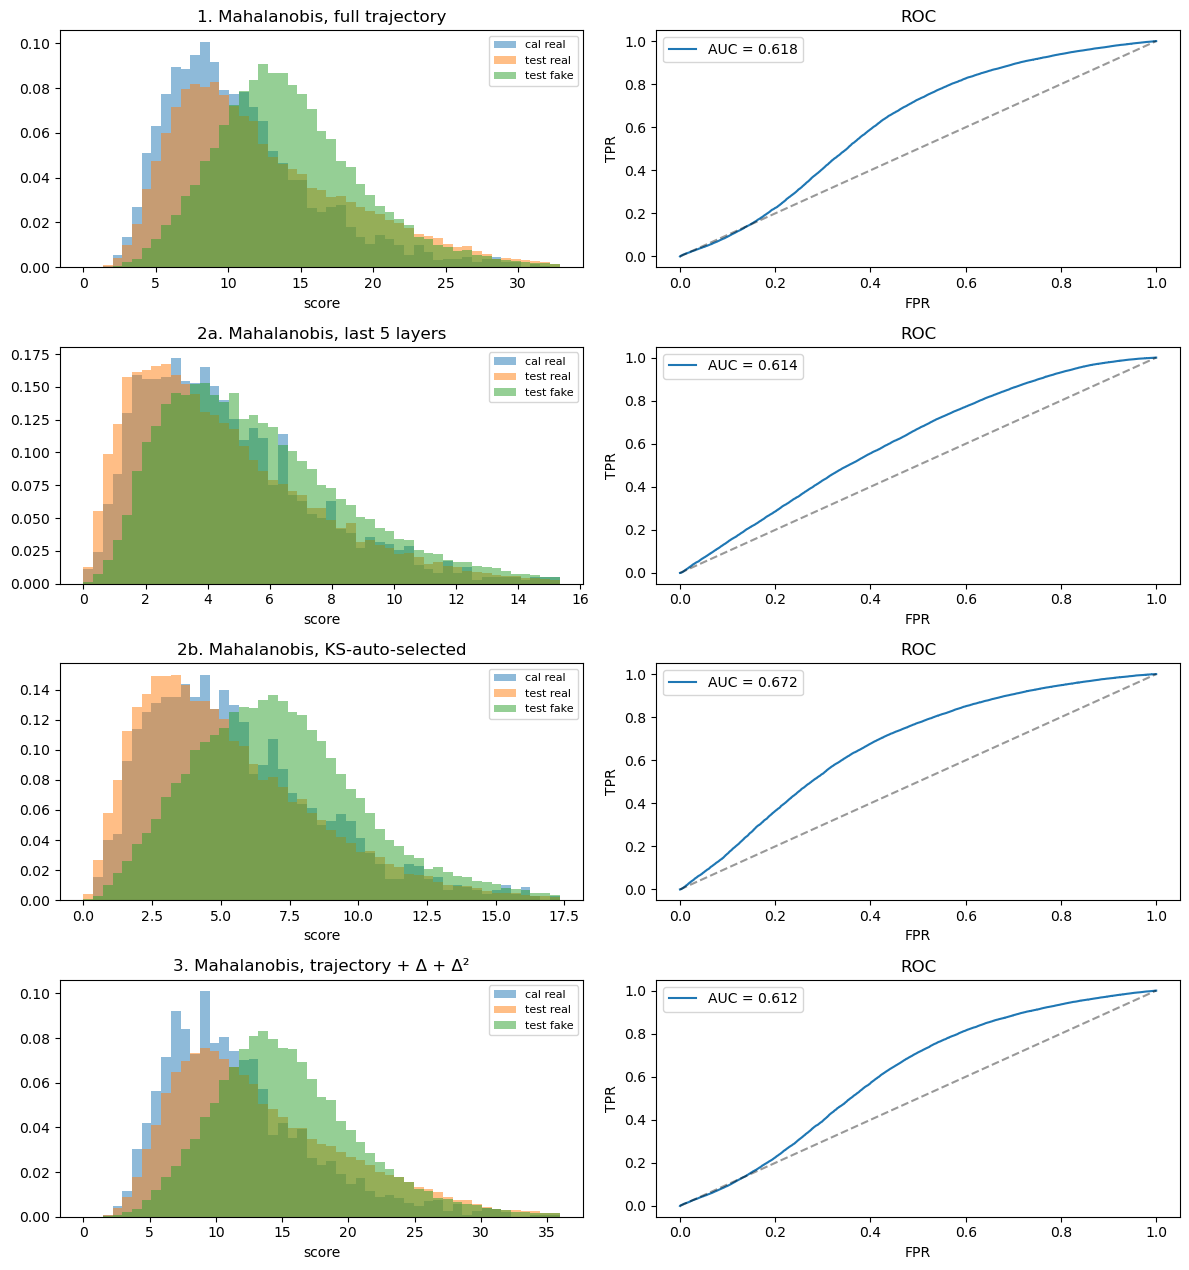


Ranked:
                             method      AUC  drift_KS  signal_KS
  2b. Mahalanobis, KS-auto-selected 0.671848  0.060585   0.280683
    1. Mahalanobis, full trajectory 0.618333  0.117645   0.232093
     2a. Mahalanobis, last 5 layers 0.613742  0.051429   0.175178
3. Mahalanobis, trajectory + Δ + Δ² 0.611814  0.125645   0.218723

→ Recommended: 2b. Mahalanobis, KS-auto-selected


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import ks_2samp

# ---------------------------------------------------------------------------
# Assumes you already have in scope:
#   cal_raw_real   : (n_cal, n_layers)   calibration reals, per-layer JEPA scores
#   test_raw       : (n_test, n_layers)  test set, per-layer JEPA scores
#   test_labels    : (n_test,)           0 = real, 1 = fake
#   layer_cols     : list of layer names, length n_layers
# ---------------------------------------------------------------------------

n_layers = cal_raw_real.shape[1]
test_real_raw = test_raw[test_labels == 0]
test_fake_raw = test_raw[test_labels == 1]

# ---------------------------------------------------------------------------
# Helper: fit Mahalanobis on cal-real, score arbitrary samples
# ---------------------------------------------------------------------------
def fit_mahalanobis(X_train):
    """Ledoit-Wolf shrinkage covariance — robust for small n / correlated dims."""
    lw = LedoitWolf().fit(X_train)
    mu = lw.location_
    Sigma_inv = np.linalg.inv(lw.covariance_)
    def score(X):
        d = X - mu
        return np.einsum("ni,ij,nj->n", d, Sigma_inv, d)
    return score

def evaluate(name, score_fn, feat_fn=lambda x: x):
    s_cal       = score_fn(feat_fn(cal_raw_real))
    s_test_real = score_fn(feat_fn(test_real_raw))
    s_test_fake = score_fn(feat_fn(test_fake_raw))
    s_test      = score_fn(feat_fn(test_raw))

    auc = roc_auc_score(test_labels, s_test)
    auc = max(auc, 1 - auc)  # sign-agnostic, like your existing code
    ks_cal_vs_treal  = ks_2samp(s_cal, s_test_real).statistic
    ks_treal_vs_tfake = ks_2samp(s_test_real, s_test_fake).statistic

    print(f"{name:<45s}  AUC={auc:.3f}   "
          f"KS(cal,test_real)={ks_cal_vs_treal:.3f}   "
          f"KS(test_real,test_fake)={ks_treal_vs_tfake:.3f}")
    return dict(name=name, auc=auc,
                ks_drift=ks_cal_vs_treal, ks_signal=ks_treal_vs_tfake,
                s_cal=s_cal, s_test_real=s_test_real, s_test_fake=s_test_fake)

# ---------------------------------------------------------------------------
# Variant 1: full-trajectory Mahalanobis (Ledoit-Wolf), fit on cal-real
# ---------------------------------------------------------------------------
score_full = fit_mahalanobis(cal_raw_real)

# ---------------------------------------------------------------------------
# Variant 2: late-layers-only Mahalanobis
#   Restricts to layers with low cal-vs-test_real drift. By default uses the
#   last 5 layers; alternatively, auto-pick layers with KS below a threshold.
# ---------------------------------------------------------------------------
# Manual choice: last 5 layers (layer_8 ... layer_norm in your setup)
late_idx_manual = np.arange(n_layers - 5, n_layers)

# Auto choice: keep layers where cal-vs-test_real KS is in the lowest half
ks_per_layer = np.array([
    ks_2samp(cal_raw_real[:, j], test_real_raw[:, j]).statistic
    for j in range(n_layers)
])
ks_threshold = np.median(ks_per_layer)
late_idx_auto = np.where(ks_per_layer <= ks_threshold)[0]

print(f"Per-layer KS(cal, test_real): {np.round(ks_per_layer, 3)}")
print(f"Manual late layers: {[layer_cols[i] for i in late_idx_manual]}")
print(f"Auto-selected (KS <= median={ks_threshold:.3f}): "
      f"{[layer_cols[i] for i in late_idx_auto]}")
print()

score_late_manual = fit_mahalanobis(cal_raw_real[:, late_idx_manual])
score_late_auto   = fit_mahalanobis(cal_raw_real[:, late_idx_auto])

# ---------------------------------------------------------------------------
# Variant 3: trajectory + 1st + 2nd differences (shape-sensitive)
# ---------------------------------------------------------------------------
def featurize_shape(x):
    d1 = np.diff(x, n=1, axis=1)
    d2 = np.diff(x, n=2, axis=1)
    return np.concatenate([x, d1, d2], axis=1)

score_shape = fit_mahalanobis(featurize_shape(cal_raw_real))

# ---------------------------------------------------------------------------
# Run them all
# ---------------------------------------------------------------------------
print("=" * 100)
print(f"{'method':<45s}  {'AUC':>5s}   {'drift (cal vs test_real)':>24s}   {'signal':>10s}")
print("=" * 100)
results = []
results.append(evaluate("1. Mahalanobis, full trajectory",       score_full))
results.append(evaluate("2a. Mahalanobis, last 5 layers",        score_late_manual,
                        feat_fn=lambda x: x[:, late_idx_manual]))
results.append(evaluate("2b. Mahalanobis, KS-auto-selected",     score_late_auto,
                        feat_fn=lambda x: x[:, late_idx_auto]))
results.append(evaluate("3. Mahalanobis, trajectory + Δ + Δ²",   score_shape,
                        feat_fn=featurize_shape))

# ---------------------------------------------------------------------------
# Plot: score histograms and ROC curves for each variant
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(len(results), 2, figsize=(12, 3.2 * len(results)))
for row, r in enumerate(results):
    # histograms
    ax = axes[row, 0]
    upper = np.quantile(np.concatenate([r["s_cal"], r["s_test_real"], r["s_test_fake"]]), 0.99)
    bins = np.linspace(0, upper, 50)
    ax.hist(r["s_cal"],       bins=bins, alpha=0.5, density=True, label="cal real")
    ax.hist(r["s_test_real"], bins=bins, alpha=0.5, density=True, label="test real")
    ax.hist(r["s_test_fake"], bins=bins, alpha=0.5, density=True, label="test fake")
    ax.set_title(r["name"]); ax.set_xlabel("score"); ax.legend(fontsize=8)

    # ROC
    ax = axes[row, 1]
    s_test = np.concatenate([r["s_test_real"], r["s_test_fake"]])
    y_test = np.concatenate([np.zeros(len(r["s_test_real"])), np.ones(len(r["s_test_fake"]))])
    # match the sign convention used for the AUC printout
    auc_raw = roc_auc_score(y_test, s_test)
    if auc_raw < 0.5:
        s_test = -s_test
    fpr, tpr, _ = roc_curve(y_test, s_test)
    ax.plot(fpr, tpr, label=f"AUC = {r['auc']:.3f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("ROC"); ax.legend()

plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# Pick the winner: best AUC, with a tie-breaker preferring lower drift
# ---------------------------------------------------------------------------
results_df = pd.DataFrame([
    {"method": r["name"], "AUC": r["auc"],
     "drift_KS": r["ks_drift"], "signal_KS": r["ks_signal"]}
    for r in results
]).sort_values(["AUC", "drift_KS"], ascending=[False, True]).reset_index(drop=True)
print("\nRanked:")
print(results_df.to_string(index=False))
print(f"\n→ Recommended: {results_df.iloc[0]['method']}")

In [8]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

mu = cal_raw_real.mean(axis=0)
sd = cal_raw_real.std(axis=0)

def report(name, s_test, s_cal=None, s_test_real=None):
    auc = roc_auc_score(test_labels, s_test)
    auc = max(auc, 1 - auc)
    extra = ""
    if s_cal is not None and s_test_real is not None:
        extra = (f"   KS(cal,test_real)={ks_2samp(s_cal, s_test_real).statistic:.3f}"
                 f"   KS(test_real,test_fake)={ks_2samp(s_test_real, s_test[test_labels==1]).statistic:.3f}")
    print(f"{name:<50s}  AUC={auc:.3f}{extra}")

# 1. sum of z-scores, all layers
z_all_test = ((test_raw - mu) / sd).sum(axis=1)
z_all_cal  = ((cal_raw_real - mu) / sd).sum(axis=1)
report("sum of z-scores, all layers", z_all_test,
       z_all_cal, z_all_test[test_labels==0])

# 1b. sum of z-scores, late layers only
z_late_test = ((test_raw - mu) / sd)[:, late_idx_manual].sum(axis=1)
z_late_cal  = ((cal_raw_real - mu) / sd)[:, late_idx_manual].sum(axis=1)
report("sum of z-scores, late layers", z_late_test,
       z_late_cal, z_late_test[test_labels==0])

# 2. best single layer (per-layer z-scores)
print("\nPer-layer z-score AUCs:")
for j, name in enumerate(layer_cols):
    z_j = (test_raw[:, j] - mu[j]) / sd[j]
    auc = roc_auc_score(test_labels, z_j)
    print(f"  {name:<12s}  AUC={max(auc, 1-auc):.3f}")

# 3. PCA residual
for k in [1, 2, 3, 5]:
    pca = PCA(n_components=k).fit(cal_raw_real)
    recon_test = pca.inverse_transform(pca.transform(test_raw))
    recon_cal  = pca.inverse_transform(pca.transform(cal_raw_real))
    s_test = ((test_raw - recon_test) ** 2).sum(axis=1)
    s_cal  = ((cal_raw_real - recon_cal) ** 2).sum(axis=1)
    report(f"PCA residual, k={k}", s_test, s_cal, s_test[test_labels==0])

sum of z-scores, all layers                         AUC=0.715   KS(cal,test_real)=0.207   KS(test_real,test_fake)=0.367
sum of z-scores, late layers                        AUC=0.768   KS(cal,test_real)=0.146   KS(test_real,test_fake)=0.436

Per-layer z-score AUCs:
  layer_1       AUC=0.680
  layer_2       AUC=0.643
  layer_3       AUC=0.645
  layer_4       AUC=0.634
  layer_5       AUC=0.622
  layer_6       AUC=0.633
  layer_7       AUC=0.659
  layer_8       AUC=0.728
  layer_9       AUC=0.750
  layer_10      AUC=0.772
  layer_11      AUC=0.778
  layer_norm    AUC=0.778
PCA residual, k=1                                   AUC=0.603   KS(cal,test_real)=0.036   KS(test_real,test_fake)=0.156
PCA residual, k=2                                   AUC=0.574   KS(cal,test_real)=0.074   KS(test_real,test_fake)=0.152
PCA residual, k=3                                   AUC=0.525   KS(cal,test_real)=0.097   KS(test_real,test_fake)=0.107
PCA residual, k=5                                   AUC=0.517  

Explained variance ratio: [8.57969884e-01 8.07154455e-02 3.64512763e-02 1.04787179e-02
 6.08240447e-03 3.40388634e-03 1.79478897e-03 1.23031777e-03
 7.01030623e-04 5.85283413e-04 3.69136998e-04 2.17828212e-04]
PC1: var=0.858, AUROC=0.7215
PC2: var=0.081, AUROC=0.5158
PC3: var=0.036, AUROC=0.7592
PC4: var=0.010, AUROC=0.7292
PC5: var=0.006, AUROC=0.6970


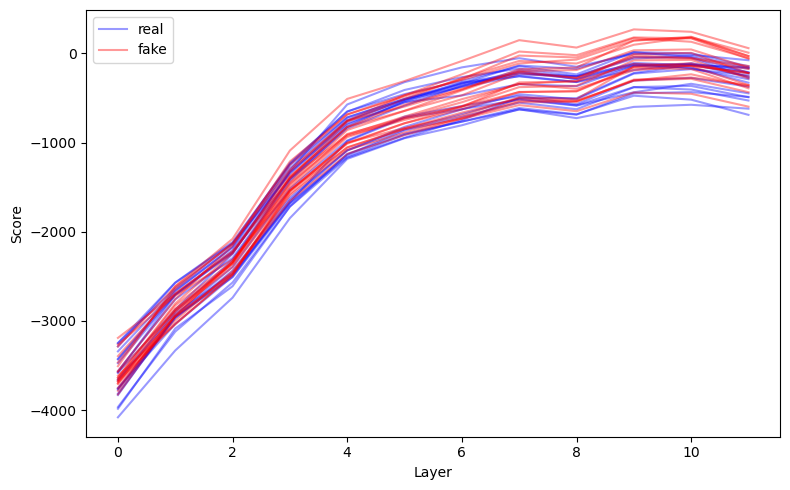

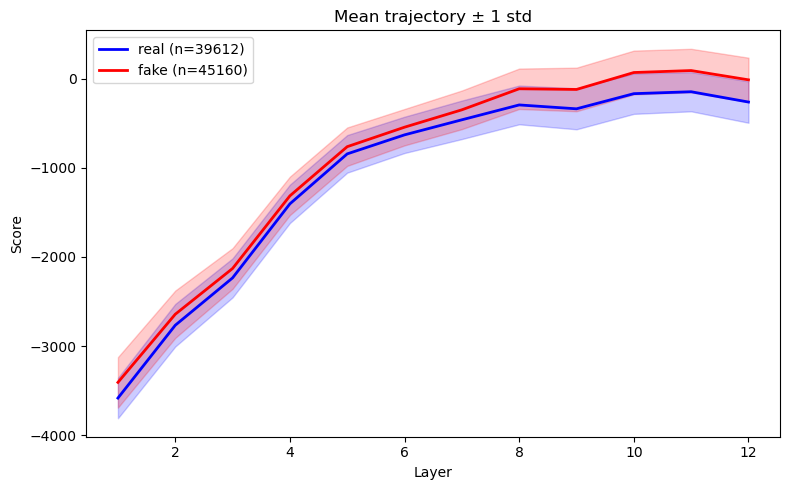

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score

cal  = pd.read_csv("layers_vit_base_patch16_clip_quickgelu_224_metaclip_400m_Imagenet.csv")
test = pd.read_csv("layers_vit_base_patch16_clip_quickgelu_224_metaclip_400m_ForenSynths.csv")

FEATURE_COLS = [f"layer_{i}" for i in range(1, 12)] + ["layer_norm"]

X_cal  = cal[FEATURE_COLS].to_numpy()
X_test = test[FEATURE_COLS].to_numpy()
y_test = test["label"].to_numpy().astype(int)

# PCA fit on calibration (reals) — proper zero-shot diagnostic
pca = PCA().fit(X_cal)
print("Explained variance ratio:", pca.explained_variance_ratio_)

pc_scores_test = pca.transform(X_test)
for k in range(min(5, pc_scores_test.shape[1])):
    auc = roc_auc_score(y_test, pc_scores_test[:, k])
    auc = max(auc, 1 - auc)
    print(f"PC{k+1}: var={pca.explained_variance_ratio_[k]:.3f}, AUROC={auc:.4f}")

# Trajectory plot
real_traj = X_test[y_test == 0][:20]
fake_traj = X_test[y_test == 1][:20]

plt.figure(figsize=(8, 5))
for i, s in enumerate(real_traj):
    plt.plot(s, color='blue', alpha=0.4, label='real' if i == 0 else None)
for i, s in enumerate(fake_traj):
    plt.plot(s, color='red', alpha=0.4, label='fake' if i == 0 else None)
plt.xlabel('Layer')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()


layer_indices = list(range(1, 12)) + [12]   # layer_1..11 + norm
real_all = X_test[y_test == 0]
fake_all = X_test[y_test == 1]

real_mean = real_all.mean(axis=0)
real_std  = real_all.std(axis=0)
fake_mean = fake_all.mean(axis=0)
fake_std  = fake_all.std(axis=0)

plt.figure(figsize=(8, 5))
plt.plot(layer_indices, real_mean, color='blue', label=f'real (n={len(real_all)})', linewidth=2)
plt.fill_between(layer_indices, real_mean - real_std, real_mean + real_std,
                 color='blue', alpha=0.2)
plt.plot(layer_indices, fake_mean, color='red', label=f'fake (n={len(fake_all)})', linewidth=2)
plt.fill_between(layer_indices, fake_mean - fake_std, fake_mean + fake_std,
                 color='red', alpha=0.2)
plt.xlabel('Layer')
plt.ylabel('Score')
plt.title('Mean trajectory ± 1 std')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# How are fakes distributed along PC4 relative to reals?
pc_cal  = pca.transform(X_cal)[:, 3]
pc_test_real = pc_scores_test[y_test == 0, 3]
pc_test_fake = pc_scores_test[y_test == 1, 3]

print(f"PC4 real (cal):  mean={pc_cal.mean():+.3f}, std={pc_cal.std():.3f}")
print(f"PC4 real (test): mean={pc_test_real.mean():+.3f}, std={pc_test_real.std():.3f}")
print(f"PC4 fake (test): mean={pc_test_fake.mean():+.3f}, std={pc_test_fake.std():.3f}")

# Same for the squared (deviation-from-mean) score
mu4 = pc_cal.mean()
print(f"\n|PC4 - mu_cal|^2:")
print(f"  real (test): {((pc_test_real - mu4)**2).mean():.3f}")
print(f"  fake (test): {((pc_test_fake - mu4)**2).mean():.3f}")

PC4 real (cal):  mean=+0.000, std=93.321
PC4 real (test): mean=-55.616, std=99.947
PC4 fake (test): mean=+23.323, std=96.085

|PC4 - mu_cal|^2:
  real (test): 13082.579
  fake (test): 9776.223


In [11]:
# Build the PC4 direction from cal
pca = PCA().fit(X_cal)
pc4_direction = pca.components_[3]   # shape [12]

# Anchor the sign: define "positive" as the direction of late-vs-early late layers
# (matches what we saw in trajectories: fakes have higher late-layer scores)
late_layers = np.array([0,0,0,0,0,0,0,0,1,1,1,1])  # late mask, layers 8-11+norm
sign = np.sign(pc4_direction @ late_layers)
pc4_anchored = pc4_direction * sign

# At test time
score = (X_test - X_cal.mean(0)) @ pc4_anchored
auc = roc_auc_score(y_test, score)
print(f"PC4 (anchored): AUROC = {max(auc, 1-auc):.4f}")

PC4 (anchored): AUROC = 0.7292


In [12]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, _) in enumerate(kf.split(X_cal)):
    pca_k = PCA().fit(X_cal[train_idx])
    direction = pca_k.components_[3] * np.sign(pca_k.components_[3] @ late_layers)
    score = (X_test - X_cal[train_idx].mean(0)) @ direction
    auc = roc_auc_score(y_test, score)
    print(f"Fold {fold}: AUROC = {max(auc, 1-auc):.4f}")

Fold 0: AUROC = 0.7334
Fold 1: AUROC = 0.7341
Fold 2: AUROC = 0.7301
Fold 3: AUROC = 0.7216
Fold 4: AUROC = 0.7260


In [13]:
for fold, (train_idx, _) in enumerate(kf.split(X_cal)):
    pca_k = PCA().fit(X_cal[train_idx])
    direction = pca_k.components_[3] * np.sign(pca_k.components_[3] @ late_layers)
    print(f"Fold {fold}: ", np.round(direction, 2))

Fold 0:  [ 0.67 -0.43 -0.48 -0.19 -0.04  0.05  0.14  0.21  0.14  0.11 -0.05 -0.06]
Fold 1:  [ 0.67 -0.41 -0.46 -0.21 -0.07  0.04  0.14  0.23  0.15  0.11 -0.05 -0.08]
Fold 2:  [ 0.67 -0.42 -0.47 -0.21 -0.05  0.05  0.14  0.21  0.14  0.1  -0.05 -0.07]
Fold 3:  [ 0.68 -0.43 -0.47 -0.2  -0.04  0.05  0.15  0.21  0.12  0.08 -0.05 -0.05]
Fold 4:  [ 0.67 -0.42 -0.47 -0.21 -0.06  0.05  0.14  0.22  0.14  0.11 -0.05 -0.09]


In [14]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import KFold


# ── Load ─────────────────────────────────────────────────────────────────
cal  = pd.read_csv("layers_vit_base_patch16_clip_quickgelu_224_metaclip_400m_Imagenet.csv")
test = pd.read_csv("layers_vit_base_patch16_clip_quickgelu_224_metaclip_400m_ForenSynths.csv")

FEATURE_COLS = [f"layer_{i}" for i in range(1, 12)] + ["layer_norm"]
X_cal  = cal[FEATURE_COLS].to_numpy()
X_test = test[FEATURE_COLS].to_numpy()
y_test = test["label"].to_numpy().astype(int)
L = X_cal.shape[1]

results = {}
def record(name, score):
    auc = roc_auc_score(y_test, score)
    results[name] = max(auc, 1 - auc)


# ── Baselines on raw layer scores ────────────────────────────────────────
for j, col in enumerate(FEATURE_COLS):
    record(f"raw/{col}", X_test[:, j])


# ── Hand-crafted layer-difference combo ──────────────────────────────────
# layer_k lives at column index k-1; layer_norm is the last column (index 11)
d86       = X_test[:, 7] - X_test[:, 5]   # layer8 - layer6
d21       = X_test[:, 1] - X_test[:, 0]   # layer2 - layer1
final     = X_test[:, 11]                  # layer_norm (final score)

def norm01(v):
    """Min-max normalize a vector to [0, 1]."""
    lo, hi = v.min(), v.max()
    return (v - lo) / (hi - lo + 1e-12)

d86_n   = norm01(d86)
d21_n   = norm01(d21)
final_n = norm01(final)

def zscore(v):
    """Z-score normalize a vector to zero mean, unit variance."""
    return (v - v.mean()) / (v.std() + 1e-12)

d86_z   = zscore(d86)
d21_z   = zscore(d21)
final_z = zscore(final)

d95 = X_test[:, 8] - X_test[:, 4]
record("handcrafted/L9-L5", d95)

d95_z = zscore(d95)
record("handcrafted_z/(L9-L5)+final", d95_z + final_z)

# ── Sum of all norm01 layer scores ───────────────────────────────────────
layer_scores_n = np.stack([norm01(X_test[:, j]) for j in range(L)], axis=1)
record("handcrafted_n/sum_all_layers", layer_scores_n.sum(axis=1))

record("handcrafted_z/(L8-L6)+(L2-L1)",        d86_z + d21_z)
record("handcrafted_z/(L8-L6)-(L2-L1)",        d86_z - d21_z)
record("handcrafted_z/(L8-L6)+final",           d86_z + final_z)
record("handcrafted_z/(L8-L6)+(L2-L1)+final",  d86_z + d21_z + final_z)
record("handcrafted_z/(L8-L6)-(L2-L1)+final",  d86_z - d21_z + final_z)

record("handcrafted/(L8-L6)+(L2-L1)",         norm01(d86) + norm01(d21))
record("handcrafted/(L8-L6)-(L2-L1)",         norm01(d86) - norm01(d21))
record("handcrafted/L8-L6",                   d86)
record("handcrafted/L2-L1",                   d21)
record("handcrafted/(L8-L6)+final",           d86_n + final_n)
record("handcrafted/(L8-L6)+(L2-L1)+final",  d86_n + d21_n + final_n)
record("handcrafted/(L8-L6)-(L2-L1)+final",  d86_n - d21_n + final_n)


# ── Engineered feature builder ───────────────────────────────────────────
def build_features(X):
    feats = [X]
    feats.append(X[:, 1:] - X[:, :-1])                              # diffs (L-1)
    feats.append(X[:, :-2] - 2*X[:, 1:-1] + X[:, 2:])               # curvature (L-2)
    pairs = [X[:, j] - X[:, i] for i in range(L) for j in range(i+1, L)]
    feats.append(np.stack(pairs, axis=1))                           # pairwise contrasts (L*(L-1)/2)
    feats.append(X.mean(1, keepdims=True))
    feats.append(X.std(1,  keepdims=True))
    feats.append(X.max(1,  keepdims=True))
    feats.append(X.min(1,  keepdims=True))
    feats.append((X.max(1) - X.min(1)).reshape(-1, 1))
    ell = np.arange(L)
    slope_intercept = np.polyfit(ell, X.T, 1).T                     # [N, 2]
    feats.append(slope_intercept)
    fitted = slope_intercept[:, 0:1] * ell + slope_intercept[:, 1:2]
    feats.append(X - fitted)                                        # residuals (L)
    return np.concatenate(feats, axis=1)


X_cal_full  = build_features(X_cal)
X_test_full = build_features(X_test)
print(f"Engineered feature dim: {X_cal_full.shape[1]}")


# ── Best single engineered feature ───────────────────────────────────────
single_aucs = [max(roc_auc_score(y_test, X_test_full[:, j]),
                   1 - roc_auc_score(y_test, X_test_full[:, j]))
               for j in range(X_test_full.shape[1])]
top_single_idx = np.argsort(single_aucs)[::-1][:5]
for idx in top_single_idx:
    results[f"engineered/feat_{idx}"] = single_aucs[idx]


# ── PCA on raw 12d scores, fit on cal ────────────────────────────────────
pca_raw = PCA().fit(X_cal)
proj_raw = pca_raw.transform(X_test)
for k in range(min(8, proj_raw.shape[1])):
    record(f"pca_raw/PC{k+1}_signed", proj_raw[:, k])

# Sign-anchored PC4 (late > early)
late_mask = np.array([0]*7 + [1]*5)
pc4 = pca_raw.components_[3]
pc4_anchored = pc4 * np.sign(pc4 @ late_mask)
record("pca_raw/PC4_anchored", (X_test - X_cal.mean(0)) @ pc4_anchored)

# K-fold stability check on PC4 (mean only)
kf_aucs = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, _ in kf.split(X_cal):
    p = PCA().fit(X_cal[train_idx])
    d = p.components_[3] * np.sign(p.components_[3] @ late_mask)
    s = (X_test - X_cal[train_idx].mean(0)) @ d
    kf_aucs.append(max(roc_auc_score(y_test, s), 1 - roc_auc_score(y_test, s)))
results["pca_raw/PC4_anchored_kfold_mean"] = np.mean(kf_aucs)
results["pca_raw/PC4_anchored_kfold_std"]  = np.std(kf_aucs)


# ── PCA on expanded features ─────────────────────────────────────────────
scaler = StandardScaler().fit(X_cal_full)
Xc_z = scaler.transform(X_cal_full)
Xt_z = scaler.transform(X_test_full)
pca_exp = PCA().fit(Xc_z)
proj_exp = pca_exp.transform(Xt_z)
for k in range(min(10, proj_exp.shape[1])):
    record(f"pca_exp/PC{k+1}_signed", proj_exp[:, k])


# ── Mahalanobis-style scores ─────────────────────────────────────────────
def safe_mahal(proj, var, k):
    k = min(k, proj.shape[1])
    # only use PCs with meaningful variance (avoid div-by-near-zero)
    valid = var[:k] > var[0] * 1e-10
    k_valid = valid.sum()
    if k_valid == 0:
        return np.zeros(proj.shape[0])
    return (proj[:, :k_valid]**2 / var[:k_valid]).sum(1)

for k in [3, 5, 10, proj_raw.shape[1]]:
    record(f"mahal_raw/top{k}", safe_mahal(proj_raw, pca_raw.explained_variance_, k))
for k in [5, 10, 20, proj_exp.shape[1]]:
    record(f"mahal_exp/top{k}", safe_mahal(proj_exp, pca_exp.explained_variance_, k))


# ── GMM on top-5 PCs ─────────────────────────────────────────────────────
for k_components in [1, 3, 5]:
    gmm_raw = GaussianMixture(n_components=k_components, random_state=0).fit(
        pca_raw.transform(X_cal)[:, :5])
    record(f"gmm_raw_top5/k={k_components}", -gmm_raw.score_samples(proj_raw[:, :5]))

    gmm_exp = GaussianMixture(n_components=k_components, random_state=0).fit(
        pca_exp.transform(Xc_z)[:, :5])
    record(f"gmm_exp_top5/k={k_components}", -gmm_exp.score_samples(proj_exp[:, :5]))


# ── Isolation Forest ─────────────────────────────────────────────────────
for name, Xc, Xt in [("raw", X_cal, X_test), ("expanded", X_cal_full, X_test_full)]:
    iso = IsolationForest(n_estimators=200, random_state=0).fit(Xc)
    record(f"isoforest/{name}", -iso.score_samples(Xt))


# ── Print everything sorted ─────────────────────────────────────────────
print("\n" + "="*60)
print(f"{'Method':45s}  AUROC")
print("="*60)
for name, auc in sorted(results.items(), key=lambda kv: -kv[1]):
    print(f"{name:45s}  {auc:.4f}")

Engineered feature dim: 118

Method                                         AUROC
handcrafted_z/(L9-L5)+final                    0.8329
handcrafted/(L8-L6)+final                      0.8306
handcrafted/(L8-L6)-(L2-L1)+final              0.8299
handcrafted_z/(L8-L6)+final                    0.8299
handcrafted_z/(L8-L6)-(L2-L1)+final            0.8293
handcrafted/L9-L5                              0.8178
engineered/feat_74                             0.8178
engineered/feat_80                             0.8169
handcrafted/L8-L6                              0.8085
engineered/feat_79                             0.8085
engineered/feat_75                             0.8077
engineered/feat_81                             0.8056
handcrafted/(L8-L6)-(L2-L1)                    0.7909
pca_exp/PC2_signed                             0.7860
handcrafted_z/(L8-L6)-(L2-L1)                  0.7833
raw/layer_norm                                 0.7778
raw/layer_11                                   0.7777


In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

# ── Config ──────────────────────────────────────────────────────────────
TEST_CSV = "layers_vit_base_patch16_clip_quickgelu_224_metaclip_400m_ForenSynths.csv"

# ── Layer combinations to evaluate ──────────────────────────────────────
# Each entry: (label, expr_fn)
# expr_fn receives X (N x 12 array, cols = layer_1..layer_11, layer_norm)
# layer_k  → X[:, k-1]   (1-indexed)
# layer_norm → X[:, 11]

def L(k): return k - 1          # layer_k column index (1-indexed)
LN = 11                          # layer_norm column index

COMBOS = [
    ("L8 - L6",                 lambda X: X[:, L(8)]  - X[:, L(6)]),
    ("L9 - L5",                 lambda X: X[:, L(9)]  - X[:, L(5)]),
    ("layer_norm",              lambda X: X[:, LN]),
    ("L9 - L6",  lambda X: X[:, L(9)] - X[:, L(6)]),   # feat_80
    ("L8 - L1",  lambda X: X[:, L(8)] - X[:, L(1)]),   # feat_39
    ("L8 - L7",  lambda X: X[:, L(8)] - X[:, L(7)]),   # feat_84
]

# ── Load ────────────────────────────────────────────────────────────────
test = pd.read_csv(TEST_CSV)
print(f"Loaded {len(test)} rows. Columns: {list(test.columns)}\n")

FEATURE_COLS = [f"layer_{i}" for i in range(1, 12)] + ["layer_norm"]
y   = test["label"].to_numpy().astype(int)
X   = test[FEATURE_COLS].to_numpy()
gen = test["img_path"].str.split("/").str[0].str.lower()

print(f"Generator distribution:\n{gen.value_counts()}\n")

# ── AUC helper ──────────────────────────────────────────────────────────
def auc_sym(y_, s_):
    if len(np.unique(y_)) < 2:
        return np.nan
    a = roc_auc_score(y_, s_)
    return max(a, 1 - a)

# ── Evaluate all combos ──────────────────────────────────────────────────
for combo_label, expr_fn in COMBOS:
    score = expr_fn(X)

    rows = []
    overall_auc = auc_sym(y, score)
    rows.append({"generator": "[POOLED ALL]",
                 "n_fake": int((y == 1).sum()),
                 "n_real": int((y == 0).sum()),
                 "auroc":  overall_auc})

    for g in sorted(gen.unique()):
        mask  = (gen.values == g)
        y_g   = y[mask]
        s_g   = score[mask]
        n_fake = int((y_g == 1).sum())
        n_real = int((y_g == 0).sum())
        if n_fake == 0 or n_real == 0:
            continue
        rows.append({"generator": g, "n_fake": n_fake,
                     "n_real": n_real, "auroc": auc_sym(y_g, s_g)})

    breakdown = pd.DataFrame(rows)
    per_gen   = breakdown.iloc[1:]["auroc"].dropna()

    print("=" * 65)
    print(f"  COMBO: {combo_label}")
    print("=" * 65)
    print(f"{'Generator':25s} {'n_fake':>8s} {'n_real':>8s} {'AUROC':>8s}")
    print("-" * 65)
    for _, r in breakdown.iterrows():
        print(f"{r['generator']:25s} {r['n_fake']:>8d} {r['n_real']:>8d} {r['auroc']:>8.4f}")
    print("=" * 65)

    if len(per_gen) > 1:
        print(f"Per-generator AUROC:  min={per_gen.min():.4f}  "
              f"median={per_gen.median():.4f}  max={per_gen.max():.4f}  "
              f"std={per_gen.std():.4f}")
    print(f"Pooled AUROC:         {overall_auc:.4f}")
    if len(per_gen) > 1:
        spread = per_gen.max() - per_gen.min()
        print(f"Range (max - min):    {spread:.4f}")
        if spread > 0.15:
            print("⚠  Large spread across generators — pooled number hides heterogeneity.")
        else:
            print("✓  Spread is moderate — pooled number is a reasonable summary.")
    print()

Loaded 84774 rows. Columns: ['label', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'layer_5', 'layer_6', 'layer_7', 'layer_8', 'layer_9', 'layer_10', 'layer_11', 'layer_norm', 'img_path']

Generator distribution:
img_path
stylegan2          15976
crn                12764
stylegan           11982
gaugan             10000
progan              8000
imle                7209
deepfake            5405
biggan              4000
stargan             3998
cyclegan            2642
whichfaceisreal     2000
san                  438
seeingdark           360
Name: count, dtype: int64

  COMBO: L8 - L6
Generator                   n_fake   n_real    AUROC
-----------------------------------------------------------------
[POOLED ALL]                 45160    39614   0.8085
biggan                        2000     2000   0.7681
crn                           6382     6382   0.9056
cyclegan                      1321     1321   0.8761
deepfake                      2698     2707   0.5997
gaugan         

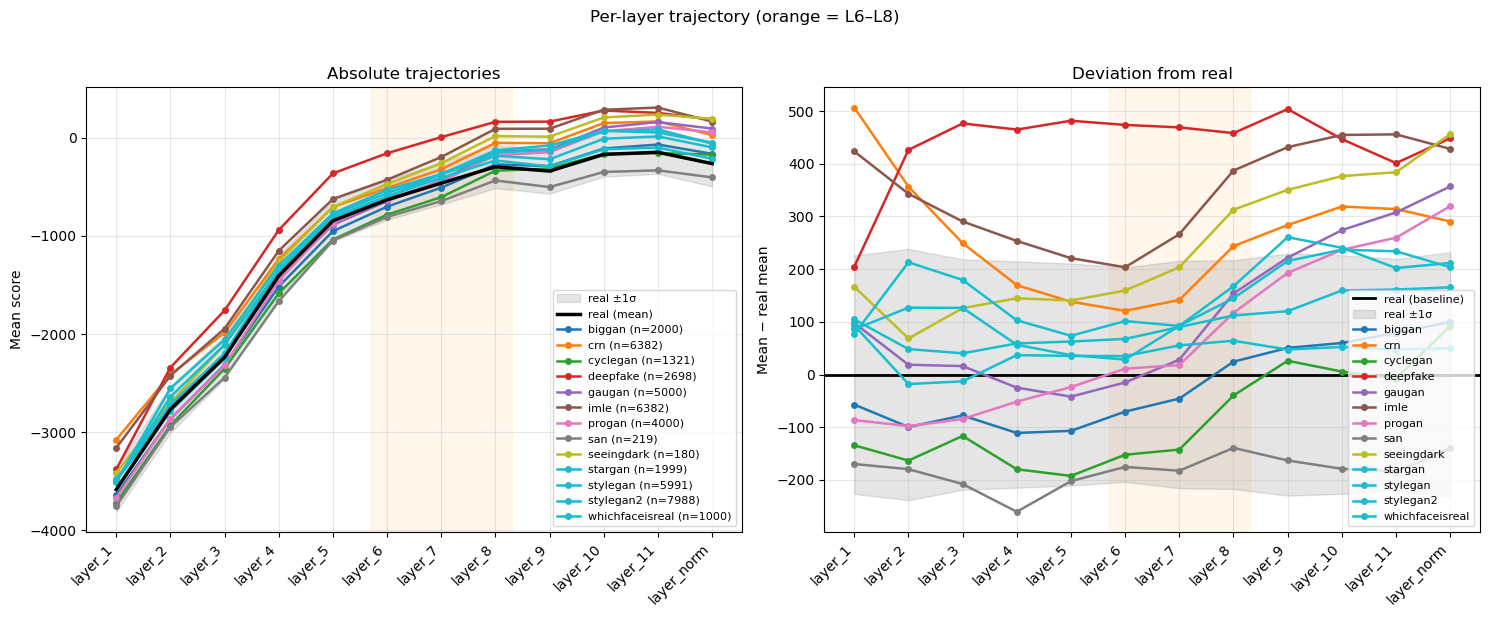

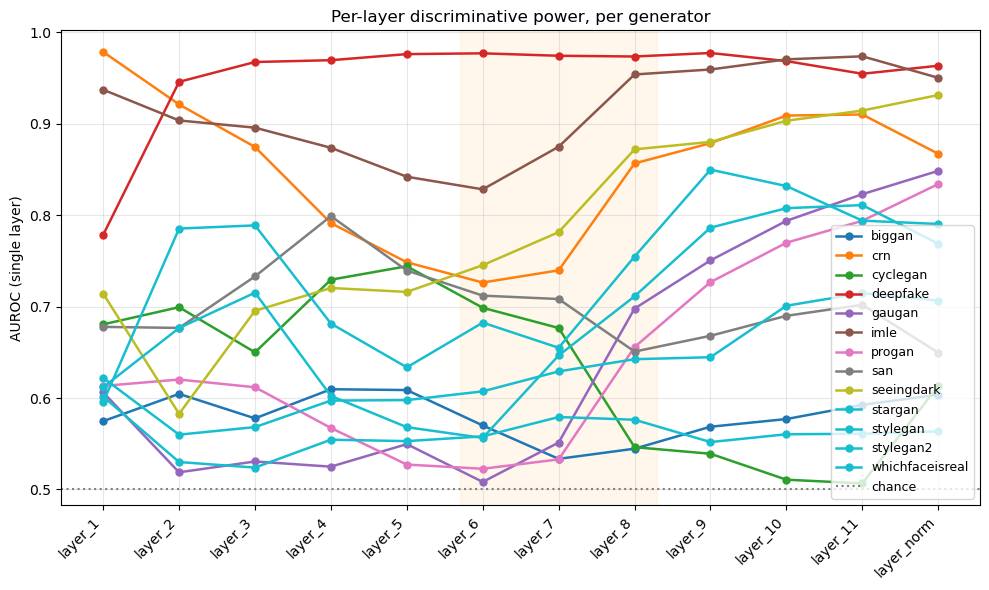

In [16]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

TEST_CSV = "layers_vit_base_patch16_clip_quickgelu_224_metaclip_400m_ForenSynths.csv"
KNOWN_GENERATORS = ["progan", "stylegan2", "stylegan", "biggan", "stargan", "gaugan",
                    "crn", "seeingdark", "imle", "cyclegan", "deepfake", "san", "whichfaceisreal",
                    "seeingdark"]

df = pd.read_csv(TEST_CSV)
FEATURE_COLS = [f"layer_{i}" for i in range(1, 12)] + ["layer_norm"]
X = df[FEATURE_COLS].to_numpy()
y = df["label"].to_numpy().astype(int)

pat = re.compile(r"(?i)(?:^|[/\\_-])(" + "|".join(KNOWN_GENERATORS) + r")(?:[/\\_-]|$)")
gen = df["img_path"].astype(str).str.extract(pat, expand=False).str.lower().fillna("unknown")

real_mask = (y == 0)
layer_idx = np.arange(len(FEATURE_COLS))
real_mean = X[real_mask].mean(0)
real_std  = X[real_mask].std(0)
generators = sorted(gen[~real_mask].unique())
cmap = plt.get_cmap("tab10")
L6, L8 = FEATURE_COLS.index("layer_6"), FEATURE_COLS.index("layer_8")


# Plot 1+2: trajectories
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.fill_between(layer_idx, real_mean - real_std, real_mean + real_std,
                color="black", alpha=0.10, label="real ±1σ")
ax.plot(layer_idx, real_mean, "k-", linewidth=2.5, label="real (mean)", zorder=10)
for i, g in enumerate(generators):
    mask = (gen == g) & ~real_mask
    if mask.sum() == 0:
        continue
    ax.plot(layer_idx, X[mask].mean(0), color=cmap(i), linewidth=1.8,
            marker="o", markersize=4, label=f"{g} (n={mask.sum()})")
ax.set_xticks(layer_idx); ax.set_xticklabels(FEATURE_COLS, rotation=45, ha="right")
ax.set_ylabel("Mean score"); ax.set_title("Absolute trajectories")
ax.axvspan(L6 - 0.3, L8 + 0.3, color="orange", alpha=0.08, zorder=0)
ax.grid(alpha=0.3); ax.legend(loc="best", fontsize=8)

ax = axes[1]
ax.axhline(0, color="black", linewidth=2, label="real (baseline)")
ax.fill_between(layer_idx, -real_std, real_std, color="black", alpha=0.10, label="real ±1σ")
for i, g in enumerate(generators):
    mask = (gen == g) & ~real_mask
    if mask.sum() == 0:
        continue
    ax.plot(layer_idx, X[mask].mean(0) - real_mean, color=cmap(i), linewidth=1.8,
            marker="o", markersize=4, label=g)
ax.set_xticks(layer_idx); ax.set_xticklabels(FEATURE_COLS, rotation=45, ha="right")
ax.set_ylabel("Mean − real mean"); ax.set_title("Deviation from real")
ax.axvspan(L6 - 0.3, L8 + 0.3, color="orange", alpha=0.08, zorder=0)
ax.grid(alpha=0.3); ax.legend(loc="best", fontsize=8)

plt.suptitle("Per-layer trajectory (orange = L6–L8)", y=1.02)
plt.tight_layout()
plt.show()


# Plot 3: per-layer AUROC per generator
def auc_sym(y_, s_):
    if len(np.unique(y_)) < 2: return np.nan
    a = roc_auc_score(y_, s_); return max(a, 1 - a)

fig2, ax = plt.subplots(figsize=(10, 6))
for i, g in enumerate(generators):
    fake_mask = (gen == g) & ~real_mask
    if fake_mask.sum() == 0:
        continue
    subset = fake_mask | real_mask
    aucs = [auc_sym(y[subset], X[subset, k]) for k in layer_idx]
    ax.plot(layer_idx, aucs, color=cmap(i), linewidth=1.8,
            marker="o", markersize=5, label=g)
ax.axhline(0.5, color="gray", linestyle=":", label="chance")
ax.set_xticks(layer_idx); ax.set_xticklabels(FEATURE_COLS, rotation=45, ha="right")
ax.set_ylabel("AUROC (single layer)")
ax.set_title("Per-layer discriminative power, per generator")
ax.axvspan(L6 - 0.3, L8 + 0.3, color="orange", alpha=0.08, zorder=0)
ax.grid(alpha=0.3); ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [17]:
pair_index = 84 - 33  # = 51
count = 0
for i in range(L):
    for j in range(i+1, L):
        if count == pair_index:
            print(f"feat_84 = X[:, {j}] - X[:, {i}]")
        count += 1

TypeError: 'function' object cannot be interpreted as an integer

In [ ]:
# Confirm what the top features actually are
for idx in [84, 18, 79, 80, 85]:
    if idx < 12:
        print(f"feat_{idx}: raw layer {idx}")
    elif idx < 23:
        i = idx - 12
        print(f"feat_{idx}: diff X[:, {i+1}] - X[:, {i}]")
    elif idx < 33:
        i = idx - 23
        print(f"feat_{idx}: curvature at layer {i+1}")
    elif idx < 99:
        pair_idx = idx - 33
        count = 0
        for i in range(L):
            for j in range(i+1, L):
                if count == pair_idx:
                    print(f"feat_{idx}: contrast X[:, {j}] - X[:, {i}]")
                count += 1
    else:
        block_offsets = {99:'mean', 100:'std', 101:'max', 102:'min', 103:'range',
                         104:'slope', 105:'intercept'}
        if idx in block_offsets:
            print(f"feat_{idx}: {block_offsets[idx]}")
        else:
            print(f"feat_{idx}: residual at layer {idx - 106}")

# Then: are these features identical to each other?
print(f"\nfeat_84 == feat_18 ?  {np.allclose(X_test_full[:, 84], X_test_full[:, 18])}")
print(f"correlation: {np.corrcoef(X_test_full[:, 84], X_test_full[:, 18])[0,1]:.4f}")

feat_84: contrast X[:, 7] - X[:, 6]
feat_18: diff X[:, 7] - X[:, 6]
feat_79: contrast X[:, 7] - X[:, 5]
feat_80: contrast X[:, 8] - X[:, 5]
feat_85: contrast X[:, 8] - X[:, 6]

feat_84 == feat_18 ?  True
correlation: 1.0000


In [ ]:
from sklearn.model_selection import train_test_split

# Hold out 30% of TEST images (NOT cal — cal already has no labels involved)
test_idx_holdout, test_idx_select = train_test_split(
    np.arange(len(y_test)), test_size=0.7, random_state=0, stratify=y_test
)

# Find best feature using only the "select" portion
single_aucs_select = [max(roc_auc_score(y_test[test_idx_select], X_test_full[test_idx_select, j]),
                          1 - roc_auc_score(y_test[test_idx_select], X_test_full[test_idx_select, j]))
                      for j in range(X_test_full.shape[1])]
best_idx = np.argmax(single_aucs_select)
auc_select = single_aucs_select[best_idx]

# Evaluate on the held-out portion
auc_holdout = roc_auc_score(y_test[test_idx_holdout], X_test_full[test_idx_holdout, best_idx])
auc_holdout = max(auc_holdout, 1 - auc_holdout)

print(f"Best feature: {best_idx}, AUROC on selection set: {auc_select:.4f}")
print(f"Same feature, AUROC on held-out:                  {auc_holdout:.4f}")

Best feature: 80, AUROC on selection set: 0.8012
Same feature, AUROC on held-out:                  0.7997


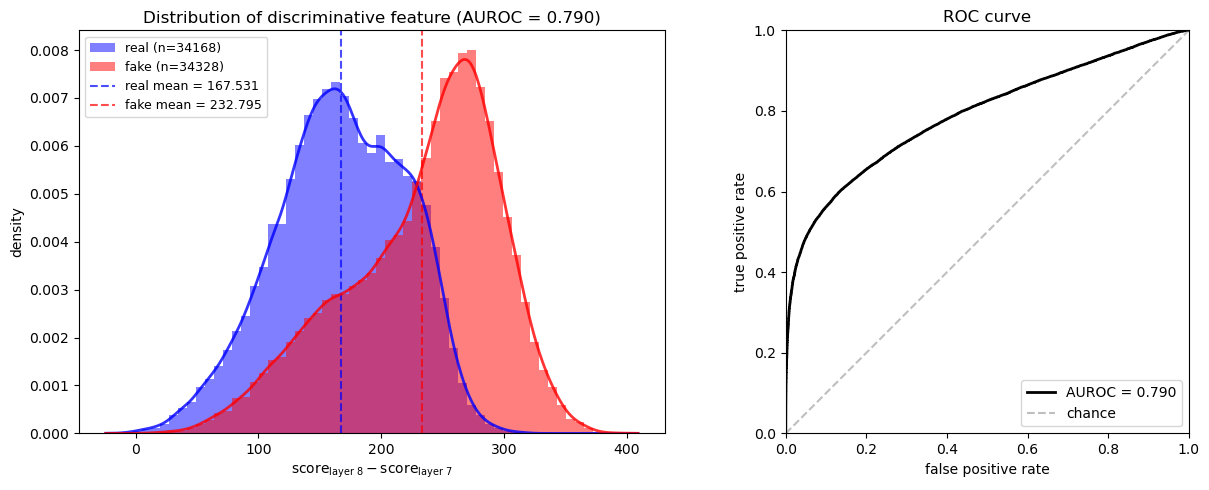

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# The discriminative feature
feat_real = X_test[y_test == 0, 7] - X_test[y_test == 0, 6]
feat_fake = X_test[y_test == 1, 7] - X_test[y_test == 1, 6]

# Compute AUROC for the title
from sklearn.metrics import roc_auc_score
score = X_test[:, 7] - X_test[:, 6]
auc = roc_auc_score(y_test, score)
auc = max(auc, 1 - auc)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Histogram ────────────────────────────────────────────────────────────
ax = axes[0]
bins = np.linspace(
    min(feat_real.min(), feat_fake.min()),
    max(feat_real.max(), feat_fake.max()),
    60,
)
ax.hist(feat_real, bins=bins, alpha=0.5, color='blue',
        label=f'real (n={len(feat_real)})', density=True)
ax.hist(feat_fake, bins=bins, alpha=0.5, color='red',
        label=f'fake (n={len(feat_fake)})', density=True)
ax.axvline(feat_real.mean(), color='blue', linestyle='--', alpha=0.7,
           label=f'real mean = {feat_real.mean():.3f}')
ax.axvline(feat_fake.mean(), color='red', linestyle='--', alpha=0.7,
           label=f'fake mean = {feat_fake.mean():.3f}')
ax.set_xlabel(r'$\mathrm{score}_{\mathrm{layer\ 8}} - \mathrm{score}_{\mathrm{layer\ 7}}$')
ax.set_ylabel('density')
ax.set_title(f'Distribution of discriminative feature (AUROC = {auc:.3f})')
ax.legend(loc='best', fontsize=9)

# ── KDE / smooth curves on the same axes via seaborn-style overlay ─────
# Done with simple Gaussian KDE for self-contained code
from scipy.stats import gaussian_kde
xs = np.linspace(bins[0], bins[-1], 400)
kde_real = gaussian_kde(feat_real)
kde_fake = gaussian_kde(feat_fake)
ax.plot(xs, kde_real(xs), color='blue', linewidth=2, alpha=0.8)
ax.plot(xs, kde_fake(xs), color='red',  linewidth=2, alpha=0.8)

# ── ROC curve ─────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, score if auc == roc_auc_score(y_test, score) else -score)
ax = axes[1]
ax.plot(fpr, tpr, color='black', linewidth=2, label=f'AUROC = {auc:.3f}')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5, label='chance')
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('ROC curve')
ax.legend(loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [ ]:
# How robust is the "feat_18 is the best" finding?
from sklearn.utils import resample

best_idx_counts = {}
for trial in range(50):
    boot_idx = resample(np.arange(len(y_test)), n_samples=len(y_test) // 2,
                        random_state=trial, stratify=y_test)
    aucs = [max(roc_auc_score(y_test[boot_idx], X_test_full[boot_idx, j]),
                1 - roc_auc_score(y_test[boot_idx], X_test_full[boot_idx, j]))
            for j in range(X_test_full.shape[1])]
    best = np.argmax(aucs)
    best_idx_counts[best] = best_idx_counts.get(best, 0) + 1

print("Top-feature distribution across bootstraps:")
for idx, count in sorted(best_idx_counts.items(), key=lambda kv: -kv[1])[:5]:
    print(f"  feat_{idx}: chosen {count}/50 times")

KeyboardInterrupt: 

In [ ]:
# Late-layer differences — captures the divergence directly
late_deltas = X_test[:, 7:] - X_test[:, 6:-1]    # diffs from layer 7→8 onward
# (adjust slice based on your column ordering)

# Late-layer slope — fit a line through layers 7..end
from numpy.polynomial import polynomial as P
late_slopes = np.array([np.polyfit(range(5), x[7:], 1)[0] for x in X_test])

# Late-vs-early contrast
late_minus_early = X_test[:, 8:].mean(1) - X_test[:, :8].mean(1)

In [ ]:
for name, feat in [('late_slope', late_slopes),
                   ('late_vs_early', late_minus_early),
                   ('layer_11_only', X_test[:, -2])]:
    auc = roc_auc_score(y_test, feat)
    auc = max(auc, 1 - auc)
    print(f"{name}: AUROC={auc:.4f}")

late_slope: AUROC=0.6317
late_vs_early: AUROC=0.7291
layer_11_only: AUROC=0.7575


In [ ]:
# Fit on calibration set (reals only)
pca_cal = PCA().fit(X_cal)

# At test time, anomaly score = squared deviation along PC4 + PC5
pc_proj_test = pca_cal.transform(X_test)
anomaly = pc_proj_test[:, 3]**2 + pc_proj_test[:, 4]**2

auc = roc_auc_score(y_test, anomaly)
auc = max(auc, 1 - auc)
print(f"PC4+PC5 anomaly: AUROC={auc:.4f}")

PC4+PC5 anomaly: AUROC=0.5277


In [ ]:
LATE_COLS = [f"layer_{i}" for i in range(8, 12)] + ["layer_norm"]
X_cal_late  = cal[LATE_COLS].to_numpy()
X_test_late = test[LATE_COLS].to_numpy()

mu  = X_cal_late.mean(0)
cov = np.cov(X_cal_late.T)
inv_cov = np.linalg.inv(cov + 1e-6 * np.eye(len(LATE_COLS)))

diff = X_test_late - mu
mahal = np.einsum('ni,ij,nj->n', diff, inv_cov, diff)

auc = roc_auc_score(y_test, mahal)
auc = max(auc, 1 - auc)
print(f"Late-layer Mahalanobis: AUROC={auc:.4f}")

ValueError: Found input variables with inconsistent numbers of samples: [67668, 67669]

In [ ]:
results = {}

# Baselines
results['layer_11'] = X_test[:, -2]   # adjust index for your norm column
results['layer_norm'] = X_test[:, -1]

# Trajectory features
results['late_slope'] = np.array([np.polyfit(range(5), x[7:], 1)[0] for x in X_test])
results['late_minus_early'] = X_test[:, 8:].mean(1) - X_test[:, :8].mean(1)

# PCA-based zero-shot
pca_cal = PCA().fit(X_cal)
proj = pca_cal.transform(X_test)
results['PC4_only'] = proj[:, 3]**2
results['PC5_only'] = proj[:, 4]**2
results['PC4_PC5'] = proj[:, 3]**2 + proj[:, 4]**2
results['PC1_to_5'] = (proj[:, :5]**2 / pca_cal.explained_variance_[:5]).sum(1)
results['mahal_full'] = (proj**2 / pca_cal.explained_variance_).sum(1)

# Late-layer Mahalanobis
LATE = [f"layer_{i}" for i in range(8, 12)] + ["layer_norm"]
X_cal_l = cal[LATE].to_numpy()
X_test_l = test[LATE].to_numpy()
mu, cov = X_cal_l.mean(0), np.cov(X_cal_l.T)
inv = np.linalg.inv(cov + 1e-6 * np.eye(len(LATE)))
diff = X_test_l - mu
results['mahal_late'] = np.einsum('ni,ij,nj->n', diff, inv, diff)

# Compare
for name, score in results.items():
    auc = max(roc_auc_score(y_test, score), 1 - roc_auc_score(y_test, score))
    print(f"{name:25s}: AUROC = {auc:.4f}")

layer_11                 : AUROC = 0.6720
layer_norm               : AUROC = 0.6717
late_slope               : AUROC = 0.5380
late_minus_early         : AUROC = 0.6753
PC4_only                 : AUROC = 0.5086
PC5_only                 : AUROC = 0.5770
PC4_PC5                  : AUROC = 0.5496
PC1_to_5                 : AUROC = 0.5572
mahal_full               : AUROC = 0.5073
mahal_late               : AUROC = 0.6025


Calibration set: n=2000 samples, p=13 features

Per-feature Gaussianity checks
feature            mean        std     skew     kurt  shapiro_p  verdict
----------------------------------------------------------------------
layer_0       -4751.356    252.617     0.18     0.14   1.94e-05  ok
layer_1       -4122.751    257.888    -0.16    -0.06   2.59e-04  ok
layer_2       -3750.185    236.936    -0.33     0.02   2.30e-08  ok
layer_3       -3047.330    246.395    -0.34    -0.08   3.53e-09  ok
layer_4       -2535.794    250.657    -0.26    -0.19   4.62e-08  ok
layer_5       -2315.999    247.537    -0.25    -0.28   9.52e-09  ok
layer_6       -2202.729    274.986    -0.30    -0.38   3.91e-11  ok
layer_7       -2150.051    273.392    -0.30    -0.33   1.24e-10  ok
layer_8       -2085.148    279.526    -0.32    -0.29   4.59e-11  ok
layer_9       -1803.560    285.364    -0.31    -0.24   5.50e-10  ok
layer_10      -1562.633    284.932    -0.29    -0.25   3.82e-09  ok
layer_11      -1301.388    27

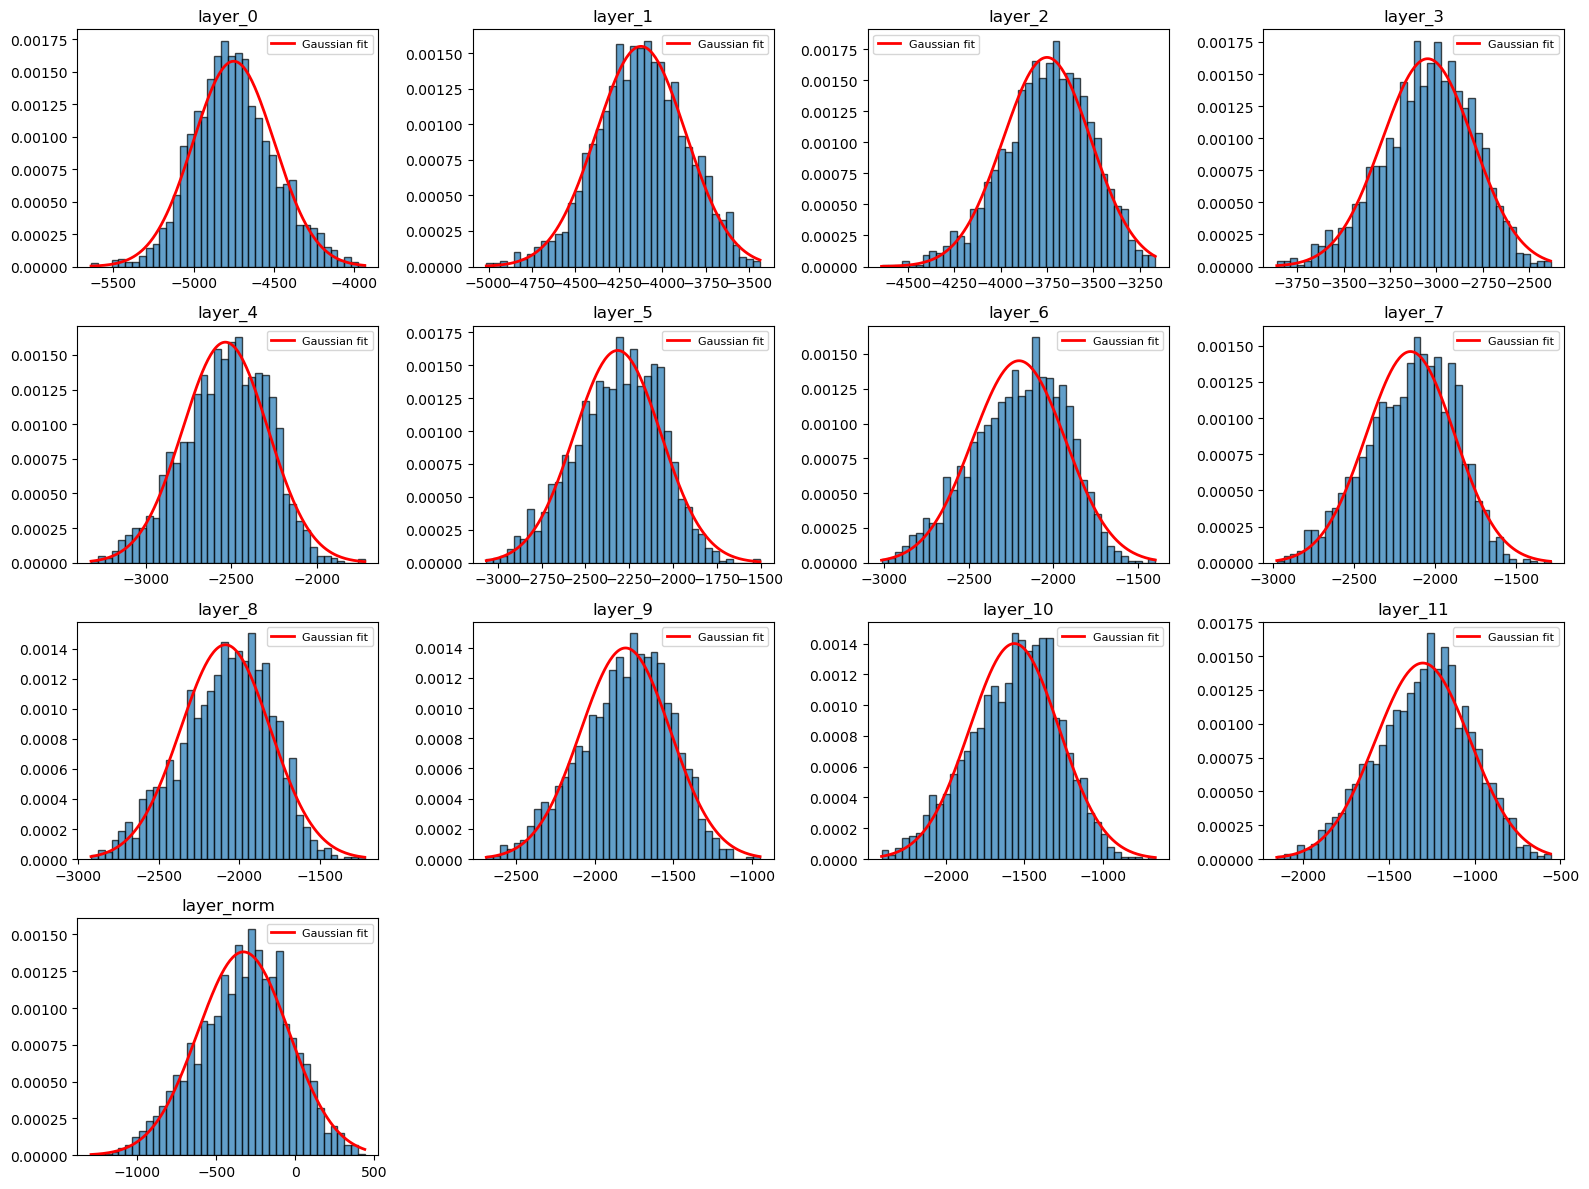

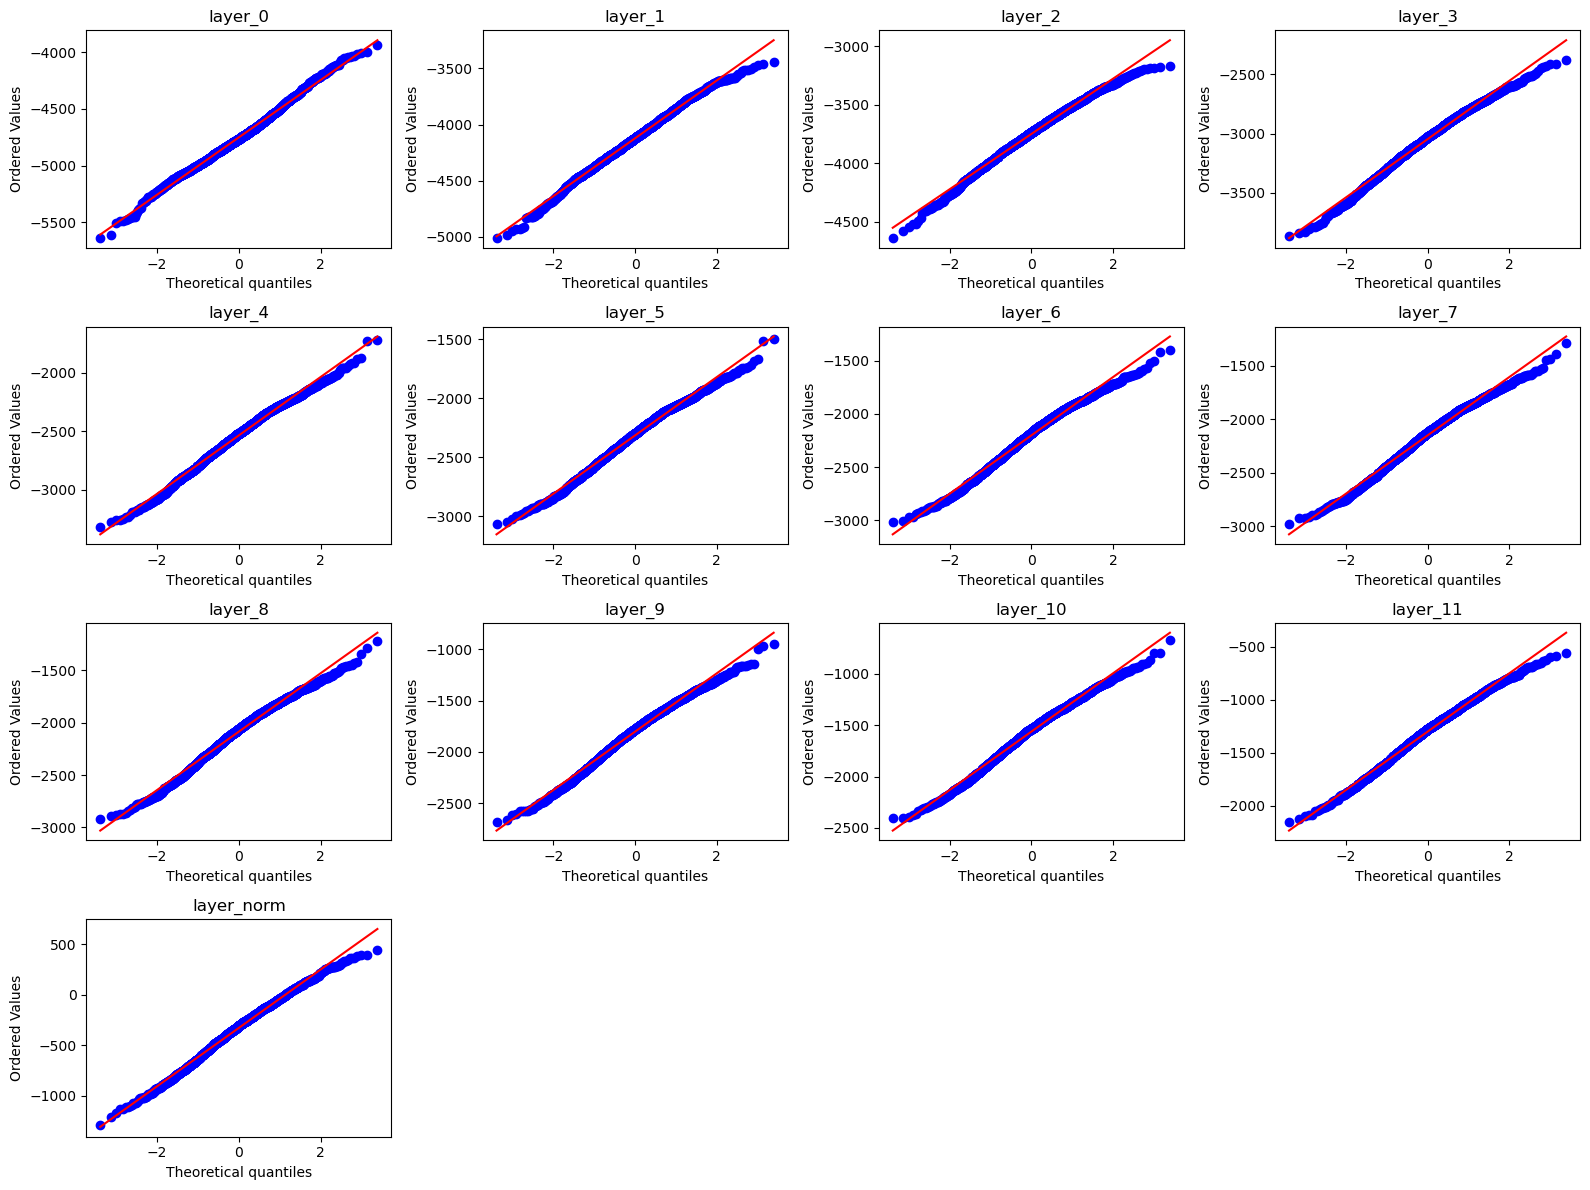

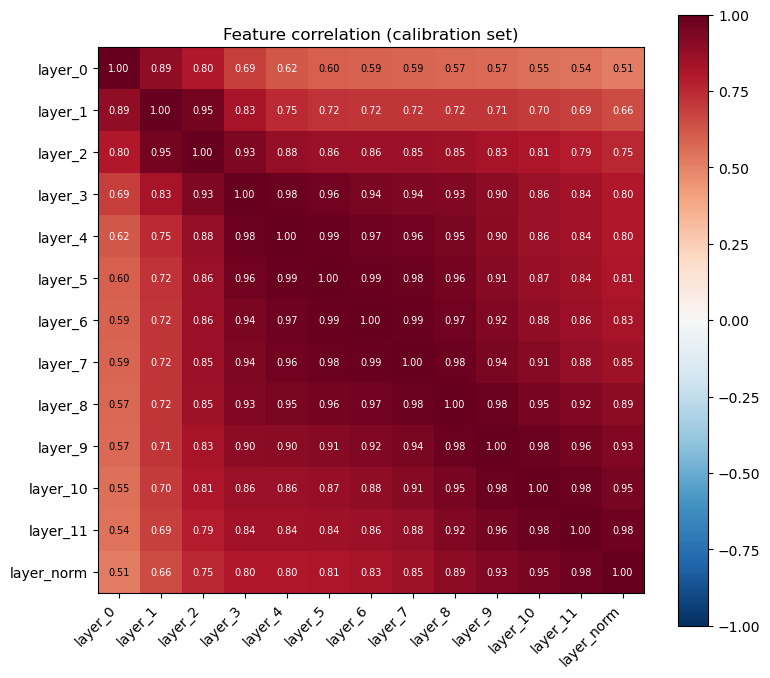

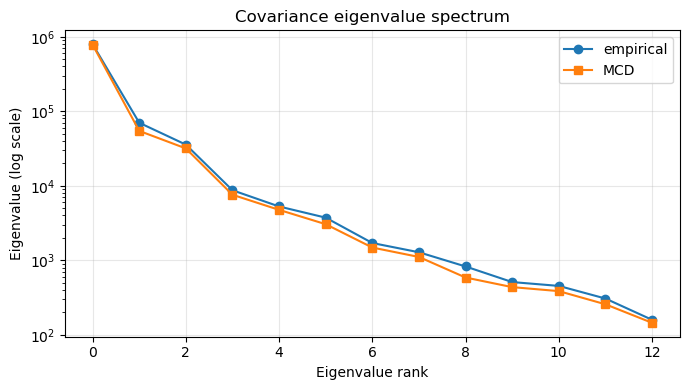

In [ ]:
"""
Diagnostics for Mahalanobis distance assumptions.

Checks:
  1. Are the features roughly Gaussian on real (calibration) images?
     - Histograms + QQ plots
     - Skewness, kurtosis, Shapiro-Wilk per feature
     - Mardia's tests for multivariate normality
  2. Are features redundant / is the covariance well-conditioned?
     - Correlation heatmap
     - Condition number
     - Eigenvalues of covariance
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.covariance import MinCovDet, EmpiricalCovariance


# ---------- Load calibration set ----------

FEATURE_COLS = [f"layer_{i}" for i in range(12)] + ["layer_norm"]
X = calib_df[FEATURE_COLS].to_numpy()
n, p = X.shape
print(f"Calibration set: n={n} samples, p={p} features\n")


# ---------- 1. Per-feature Gaussianity ----------
print("=" * 70)
print("Per-feature Gaussianity checks")
print("=" * 70)
print(f"{'feature':<12s} {'mean':>10s} {'std':>10s} {'skew':>8s} {'kurt':>8s} "
      f"{'shapiro_p':>10s}  verdict")
print("-" * 70)

skewed_features = []
for i, col in enumerate(FEATURE_COLS):
    x = X[:, i]
    sk = stats.skew(x)
    ku = stats.kurtosis(x)  # excess kurtosis (0 = normal)
    # Shapiro-Wilk: H0 = normal. p < 0.05 means reject normality.
    # With large n it almost always rejects, so treat as a soft signal.
    if n <= 5000:
        _, sw_p = stats.shapiro(x)
    else:
        _, sw_p = stats.shapiro(np.random.choice(x, 5000, replace=False))

    flags = []
    if abs(sk) > 1.0:
        flags.append("skewed")
        skewed_features.append(col)
    if abs(ku) > 3.0:
        flags.append("heavy-tailed")
    verdict = ", ".join(flags) if flags else "ok"

    print(f"{col:<12s} {x.mean():>10.3f} {x.std():>10.3f} {sk:>8.2f} {ku:>8.2f} "
          f"{sw_p:>10.2e}  {verdict}")

if skewed_features:
    print(f"\n→ Consider log/Box-Cox transform on: {skewed_features}")


# ---------- 2. Histograms + QQ plots ----------
ncols = 4
nrows = int(np.ceil(p / ncols))

# Histograms
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
for i, col in enumerate(FEATURE_COLS):
    ax = axes.flat[i]
    ax.hist(X[:, i], bins=40, density=True, alpha=0.7, edgecolor="black")
    # Overlay fitted Gaussian
    mu, sd = X[:, i].mean(), X[:, i].std()
    xs = np.linspace(X[:, i].min(), X[:, i].max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, mu, sd), "r-", lw=2, label="Gaussian fit")
    ax.set_title(col)
    ax.legend(fontsize=8)
for j in range(p, nrows * ncols):
    axes.flat[j].axis("off")
plt.tight_layout()
plt.savefig("histograms.png", dpi=100, bbox_inches="tight")
print("\nSaved: histograms.png")

# QQ plots — straight line = Gaussian
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
for i, col in enumerate(FEATURE_COLS):
    ax = axes.flat[i]
    stats.probplot(X[:, i], dist="norm", plot=ax)
    ax.set_title(col)
for j in range(p, nrows * ncols):
    axes.flat[j].axis("off")
plt.tight_layout()
plt.savefig("qqplots.png", dpi=100, bbox_inches="tight")
print("Saved: qqplots.png")


# ---------- 3. Multivariate normality (Mardia's tests) ----------
print("\n" + "=" * 70)
print("Multivariate normality (Mardia)")
print("=" * 70)

def mardia(X):
    """Mardia's skewness and kurtosis tests for multivariate normality."""
    n, p = X.shape
    Xc = X - X.mean(axis=0)
    S = np.cov(X, rowvar=False)
    S_inv = np.linalg.pinv(S)
    D = Xc @ S_inv @ Xc.T  # n x n

    # Skewness
    b1p = (D ** 3).sum() / (n ** 2)
    skew_stat = n * b1p / 6
    skew_df = p * (p + 1) * (p + 2) / 6
    skew_p = 1 - stats.chi2.cdf(skew_stat, df=skew_df)

    # Kurtosis
    b2p = np.trace(D ** 2) / n if False else (np.diag(D) ** 2).mean()
    # standard form:
    b2p = (np.diag(D) ** 2).mean()
    kurt_stat = (b2p - p * (p + 2)) / np.sqrt(8 * p * (p + 2) / n)
    kurt_p = 2 * (1 - stats.norm.cdf(abs(kurt_stat)))

    return skew_stat, skew_p, kurt_stat, kurt_p

ss, sp, ks, kp = mardia(X)
print(f"Mardia skewness  stat={ss:>10.2f}  p={sp:.2e}  "
      f"({'reject MVN' if sp < 0.05 else 'consistent with MVN'})")
print(f"Mardia kurtosis  stat={ks:>10.2f}  p={kp:.2e}  "
      f"({'reject MVN' if kp < 0.05 else 'consistent with MVN'})")
print("Note: with large n these almost always reject; use as a soft signal\n"
      "alongside the QQ plots and per-feature checks.")


# ---------- 4. Correlation & redundancy ----------
print("\n" + "=" * 70)
print("Correlation structure")
print("=" * 70)

corr = np.corrcoef(X, rowvar=False)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(p)); ax.set_xticklabels(FEATURE_COLS, rotation=45, ha="right")
ax.set_yticks(range(p)); ax.set_yticklabels(FEATURE_COLS)
for i in range(p):
    for j in range(p):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center",
                fontsize=7, color="black" if abs(corr[i, j]) < 0.6 else "white")
plt.colorbar(im, ax=ax)
plt.title("Feature correlation (calibration set)")
plt.tight_layout()
plt.savefig("correlation.png", dpi=100, bbox_inches="tight")
print("Saved: correlation.png")

# Flag highly correlated pairs
print("\nHighly correlated pairs (|r| > 0.95):")
high_corr = []
for i in range(p):
    for j in range(i + 1, p):
        if abs(corr[i, j]) > 0.95:
            high_corr.append((FEATURE_COLS[i], FEATURE_COLS[j], corr[i, j]))
            print(f"  {FEATURE_COLS[i]:<12s} <-> {FEATURE_COLS[j]:<12s}  r={corr[i,j]:+.3f}")
if not high_corr:
    print("  (none — good)")


# ---------- 5. Conditioning of the covariance ----------
print("\n" + "=" * 70)
print("Covariance conditioning")
print("=" * 70)

cov_emp = EmpiricalCovariance().fit(X).covariance_
cov_mcd = MinCovDet(random_state=0).fit(X).covariance_

for name, C in [("empirical", cov_emp), ("MCD (robust)", cov_mcd)]:
    cond = np.linalg.cond(C)
    eigs = np.sort(np.linalg.eigvalsh(C))
    print(f"{name:>14s}: cond={cond:.2e}  "
          f"eig_min={eigs[0]:.3e}  eig_max={eigs[-1]:.3e}")
    if cond > 1e4:
        print(f"  ⚠  condition number high — covariance is near-singular, "
              f"Mahalanobis may be unstable")
    elif cond > 1e3:
        print(f"  ⚠  condition number moderate — watch for instability")
    else:
        print(f"  ✓  well-conditioned")

# Eigenvalue plot — look for tiny eigenvalues = redundant directions
plt.figure(figsize=(7, 4))
plt.semilogy(np.sort(np.linalg.eigvalsh(cov_emp))[::-1], "o-", label="empirical")
plt.semilogy(np.sort(np.linalg.eigvalsh(cov_mcd))[::-1], "s-", label="MCD")
plt.xlabel("Eigenvalue rank")
plt.ylabel("Eigenvalue (log scale)")
plt.title("Covariance eigenvalue spectrum")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("eigenvalues.png", dpi=100, bbox_inches="tight")
print("\nSaved: eigenvalues.png")
print("→ A sharp drop-off at the end means redundant directions; "
      "a flat spectrum is ideal.")


# ---------- 6. Quick try: do log-transformed features look more Gaussian? ----------
# Only meaningful if features are positive. Your `layer_*` values look mostly
# negative, so a sign-flip + log might help, or use Yeo-Johnson which handles any sign.
print("\n" + "=" * 70)
print("Yeo-Johnson transform comparison (handles negative values)")
print("=" * 70)
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson", standardize=True).fit(X)
X_yj = pt.transform(X)

print(f"{'feature':<12s} {'skew_raw':>10s} {'skew_yj':>10s} {'kurt_raw':>10s} {'kurt_yj':>10s}")
print("-" * 56)
for i, col in enumerate(FEATURE_COLS):
    print(f"{col:<12s} "
          f"{stats.skew(X[:, i]):>10.2f} {stats.skew(X_yj[:, i]):>10.2f} "
          f"{stats.kurtosis(X[:, i]):>10.2f} {stats.kurtosis(X_yj[:, i]):>10.2f}")
print("\nIf yj numbers are much closer to 0, fit Mahalanobis on the transformed\n"
      "features instead (apply the same fitted transform to test data).")

In [ ]:
from sklearn.covariance import LedoitWolf, MinCovDet, EmpiricalCovariance
from sklearn.metrics import roc_auc_score

for name, est in [("empirical", EmpiricalCovariance()),
                  ("ledoit-wolf", LedoitWolf()),
                  ("mcd", MinCovDet(random_state=0))]:
    est.fit(X_calib)
    scores = est.mahalanobis(X_test)
    auc = roc_auc_score(y_test, scores)
    cond = np.linalg.cond(est.covariance_)
    print(f"{name:>12s}  cond={cond:.1e}  AUC={auc:.4f}")

# And the subset approach:
keep = [0, 2, 4, 7, 10, 12]  # column indices
est = EmpiricalCovariance().fit(X_calib[:, keep])
scores = est.mahalanobis(X_test[:, keep])
print(f"  subset(6)  cond={np.linalg.cond(est.covariance_):.1e}  "
      f"AUC={roc_auc_score(y_test, scores):.4f}")

   empirical  cond=1.9e+02  AUC=0.4639
 ledoit-wolf  cond=1.7e+02  AUC=0.4666
         mcd  cond=1.8e+02  AUC=0.4609


IndexError: index 4 is out of bounds for axis 1 with size 3

In [ ]:
"""
Mahalanobis distance outlier detection with evaluation.

Calibration set: real images only (label=0), used to fit mu and Sigma.
Test set: mix of real (0) and fake (1). Fakes should have larger Mahalanobis distance.
"""

import numpy as np
import pandas as pd
from sklearn.covariance import MinCovDet, EmpiricalCovariance
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    roc_curve,
)
from scipy.stats import chi2


# ---------- 1. Load data ----------
# Adjust paths as needed
calib_df = pd.read_csv("layers_vit_base_patch16_clip_quickgelu_224_metaclip_400m_Imagenet.csv")
test_df = pd.read_csv("layers_vit_base_patch16_clip_quickgelu_224_metaclip_400m_ForenSynths.csv")

FEATURE_COLS = ['layer_norm']
#[f"layer_{i}" for i in range(12)] + ["layer_norm"]  # 13 features
# If you only want the 12 layer scores, use:
# FEATURE_COLS = [f"layer_{i}" for i in range(12)]

X_calib = calib_df[FEATURE_COLS].to_numpy()
X_test = test_df[FEATURE_COLS].to_numpy()
y_test = test_df["label"].to_numpy().astype(int)  # 0=real, 1=fake


# ---------- 2. Fit Mahalanobis on calibration (real only) ----------
# Sanity check: calibration set should be all real
assert (calib_df["label"] == 0).all(), "Calibration set should contain only real images"

# Robust estimator (MinCovDet) is safer; switch to EmpiricalCovariance if you trust the calib set
estimator = MinCovDet(random_state=0).fit(X_calib)
# estimator = EmpiricalCovariance().fit(X_calib)

# Squared Mahalanobis distances — higher = more outlier-like = more likely fake
scores_test = estimator.mahalanobis(X_test)
scores_calib = estimator.mahalanobis(X_calib)


# ---------- 3. Threshold-independent metrics ----------
# These use the raw scores; no threshold needed
auc = roc_auc_score(y_test, scores_test)
ap = average_precision_score(y_test, scores_test)

print(f"AUROC: {auc:.4f}")
print(f"AP   : {ap:.4f}")


# ---------- 4. Pick a threshold, then compute accuracy & F1 ----------
# Three common options — pick whichever fits your use case:

# (a) Empirical: 95th/97.5th/99th percentile of calibration distances
threshold_emp = np.quantile(scores_calib, 0.975)

# (b) Chi-squared: assumes features are multivariate Gaussian on real data
threshold_chi2 = chi2.ppf(0.975, df=X_calib.shape[1])

# (c) Optimal on test set (Youden's J — useful for diagnostic, but optimistic
#     because the threshold is tuned on the test set itself)
fpr, tpr, thr = roc_curve(y_test, scores_test)
threshold_youden = thr[np.argmax(tpr - fpr)]

for name, t in [("empirical_97.5%", threshold_emp),
                ("chi2_97.5%",      threshold_chi2),
                ("youden_optimal",  threshold_youden)]:
    y_pred = (scores_test > t).astype(int)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{name:>18s}  thr={t:8.2f}  acc={acc:.4f}  f1={f1:.4f}")

AUROC: 0.5959
AP   : 0.7302
   empirical_97.5%  thr=    5.58  acc=0.3650  f1=0.0218
        chi2_97.5%  thr=    5.02  acc=0.3676  f1=0.0296
    youden_optimal  thr=    0.51  acc=0.5456  f1=0.5592


calibration:  n=2000
test real:    n=1009
test fake:    n=1997
Saved: layer_histograms.png
Saved: layer_kde.png


/tmp/ipykernel_3709558/330183869.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3709558/330183869.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3709558/330183869.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3709558/330183869.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3709558/330183869.py:94: MatplotlibDeprecationWarning: The 'labels' param

Saved: layer_boxplots.png
Saved: layer_qq_calib_vs_test.png

Per-layer summary (mean ± std) and KS distance from calibration
feature                     calib            test real            test fake   KS_real   KS_fake
----------------------------------------------------------------------------------------
layer_0         -4751.4 ±  252.6    -4694.2 ±  199.2    -4643.4 ±  199.6     0.146     0.232
layer_1         -4122.8 ±  257.9    -4027.3 ±  168.0    -4022.6 ±  177.3     0.240     0.229
layer_2         -3750.2 ±  236.9    -3681.8 ±  148.4    -3678.9 ±  151.1     0.196     0.206
layer_3         -3047.3 ±  246.4    -2927.7 ±  161.4    -2913.5 ±  167.0     0.254     0.283
layer_4         -2535.8 ±  250.7    -2429.7 ±  166.1    -2433.3 ±  178.2     0.236     0.229
layer_5         -2316.0 ±  247.5    -2237.7 ±  163.6    -2243.3 ±  176.1     0.202     0.186
layer_6         -2202.7 ±  275.0    -2149.8 ±  179.9    -2156.7 ±  201.4     0.161     0.130
layer_7         -2150.1 ±  273.4    -21

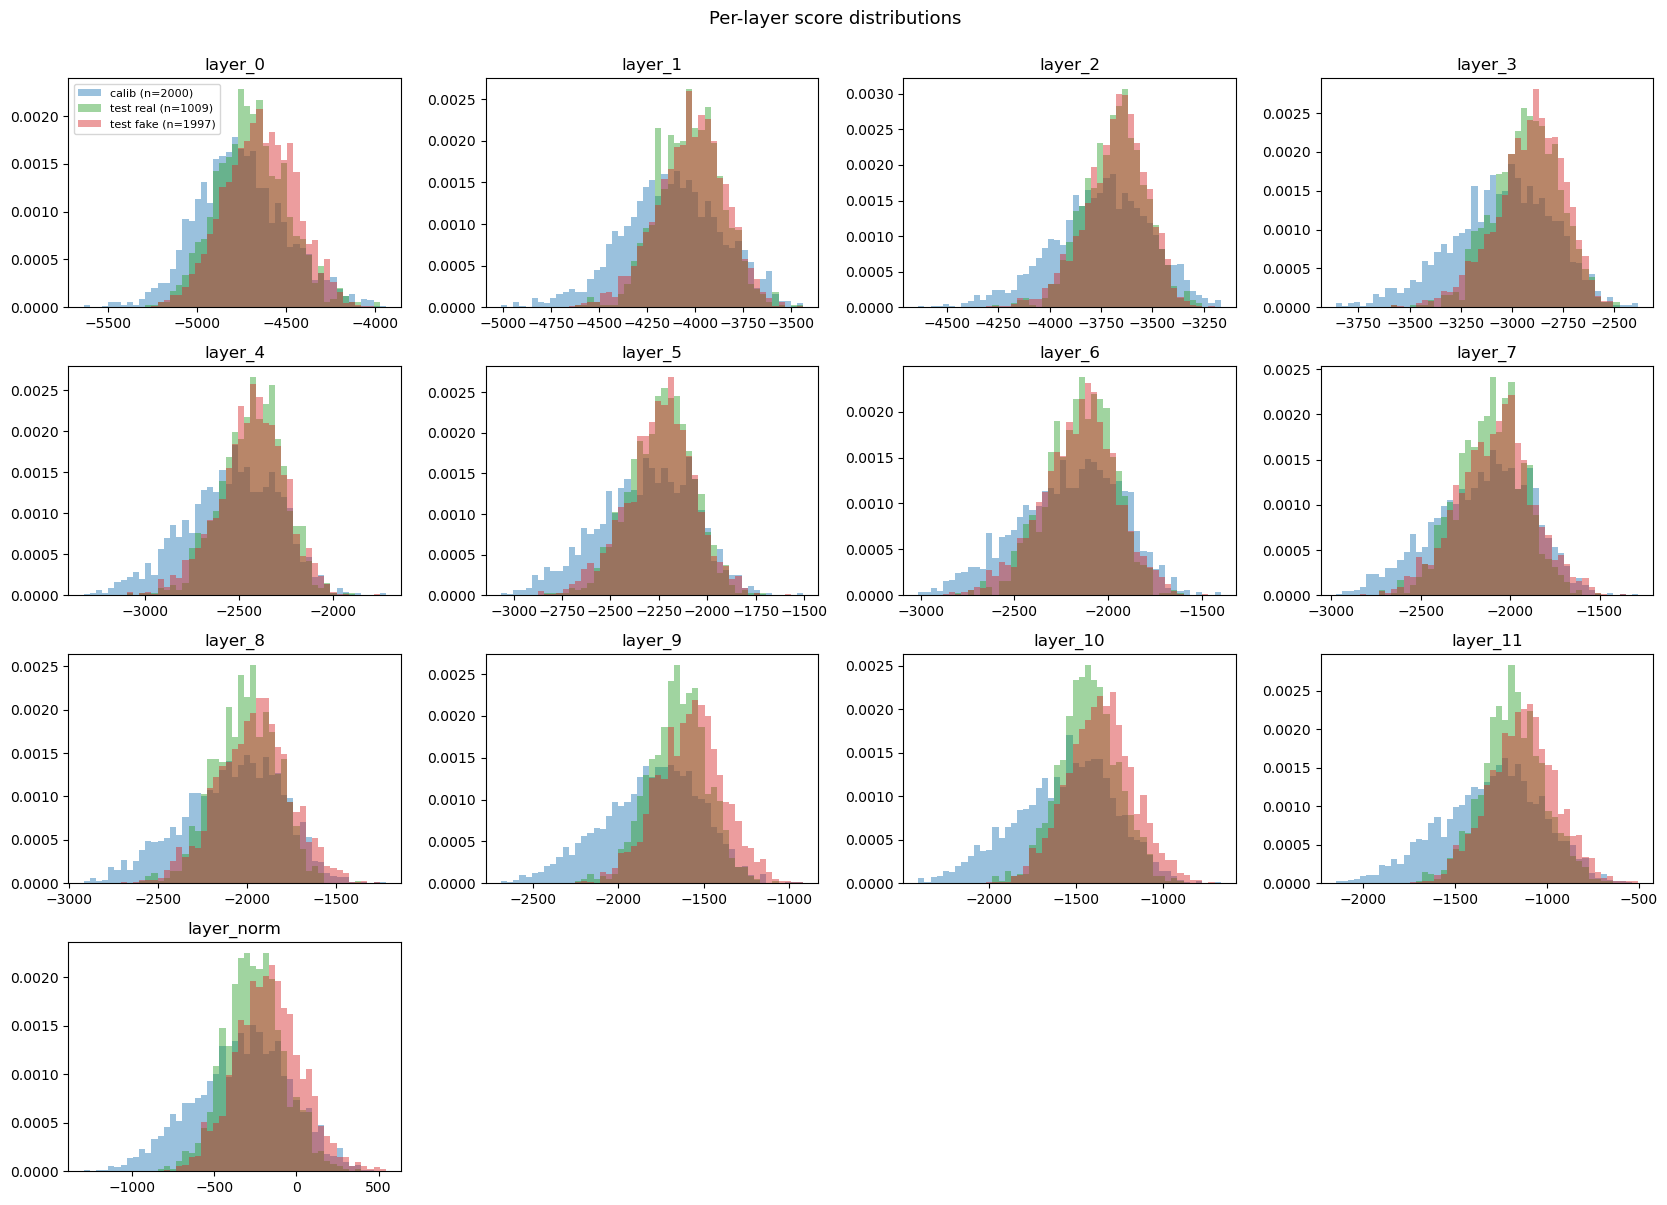

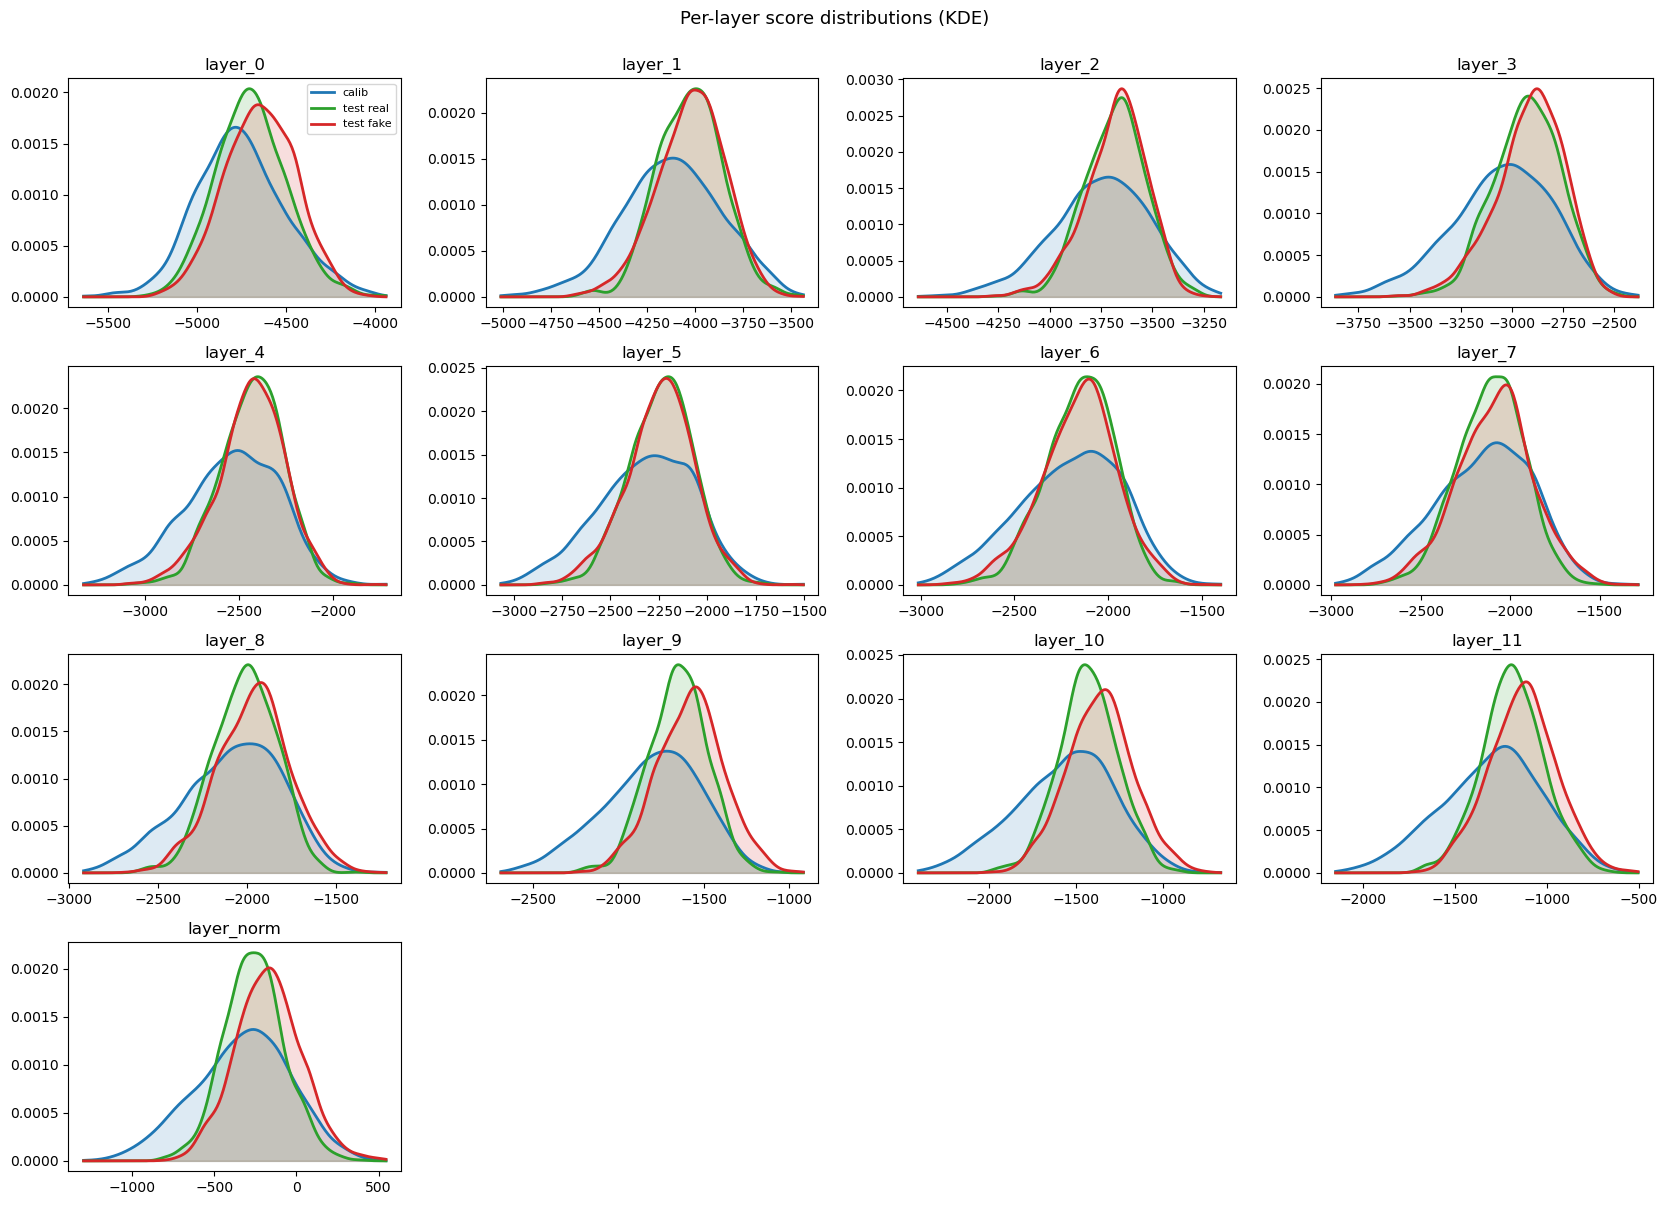

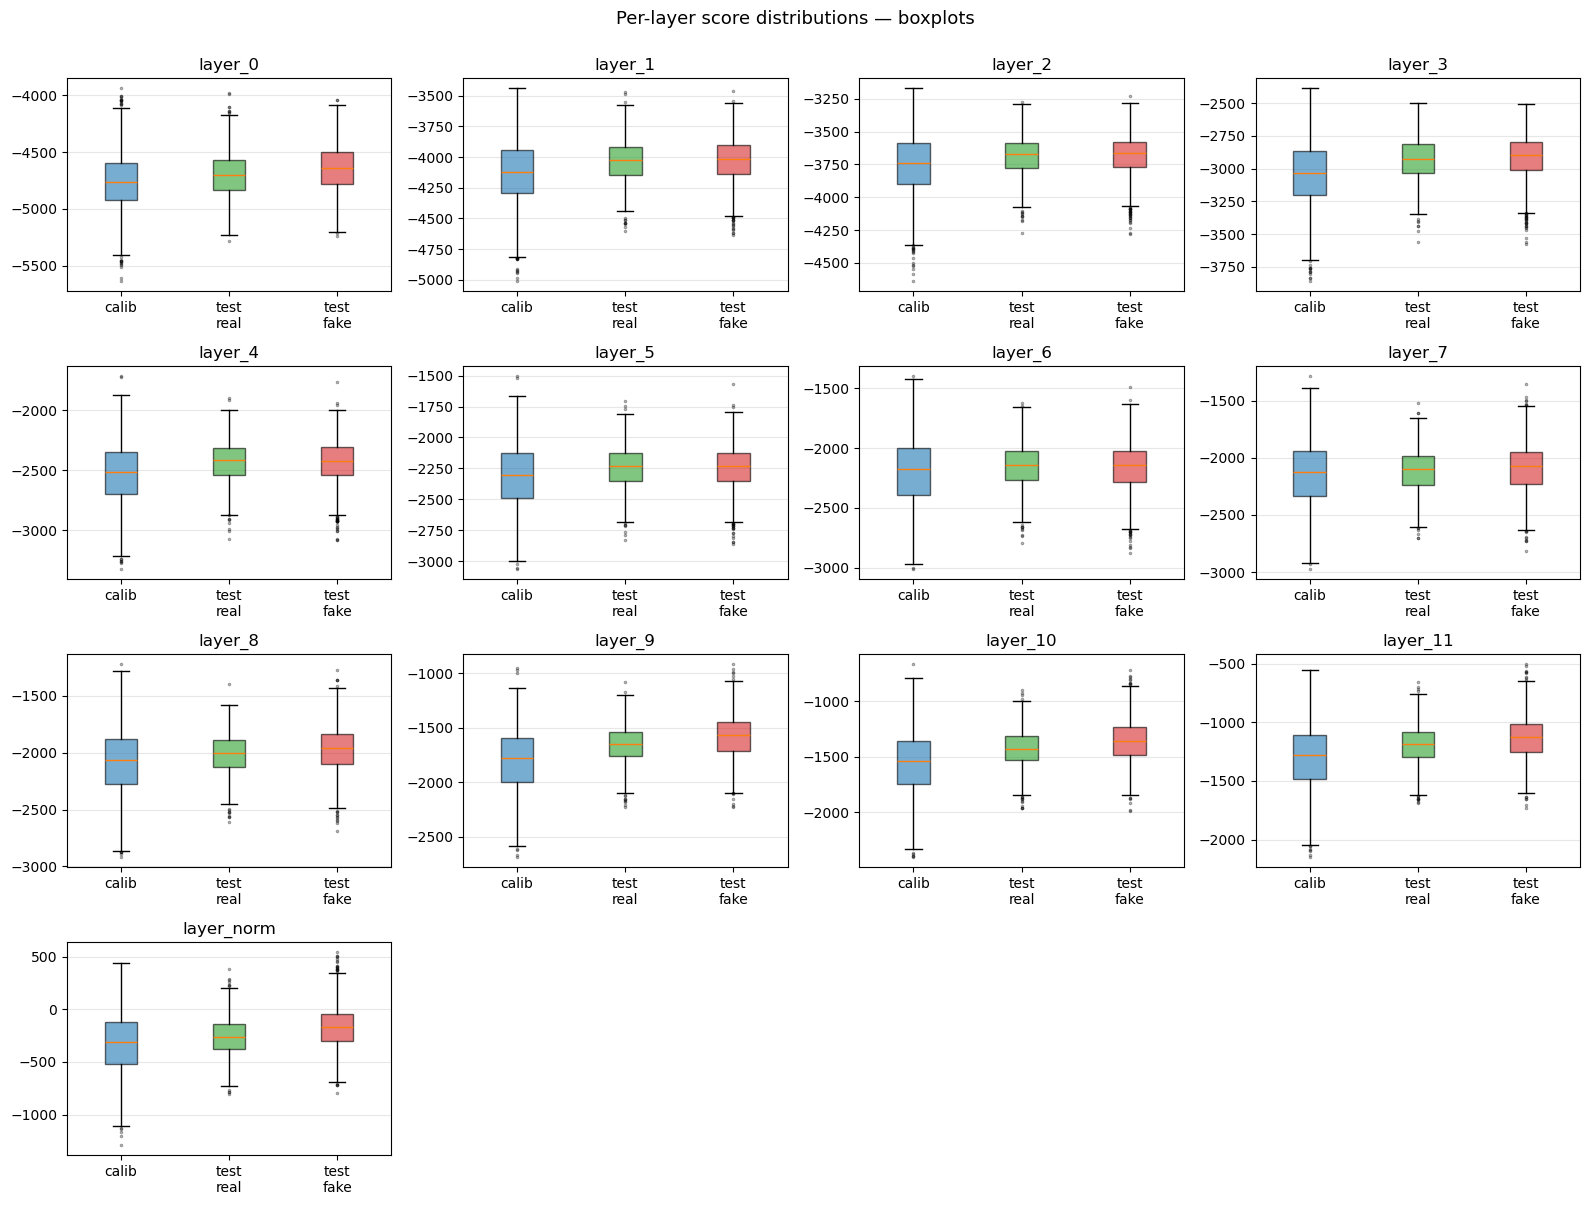

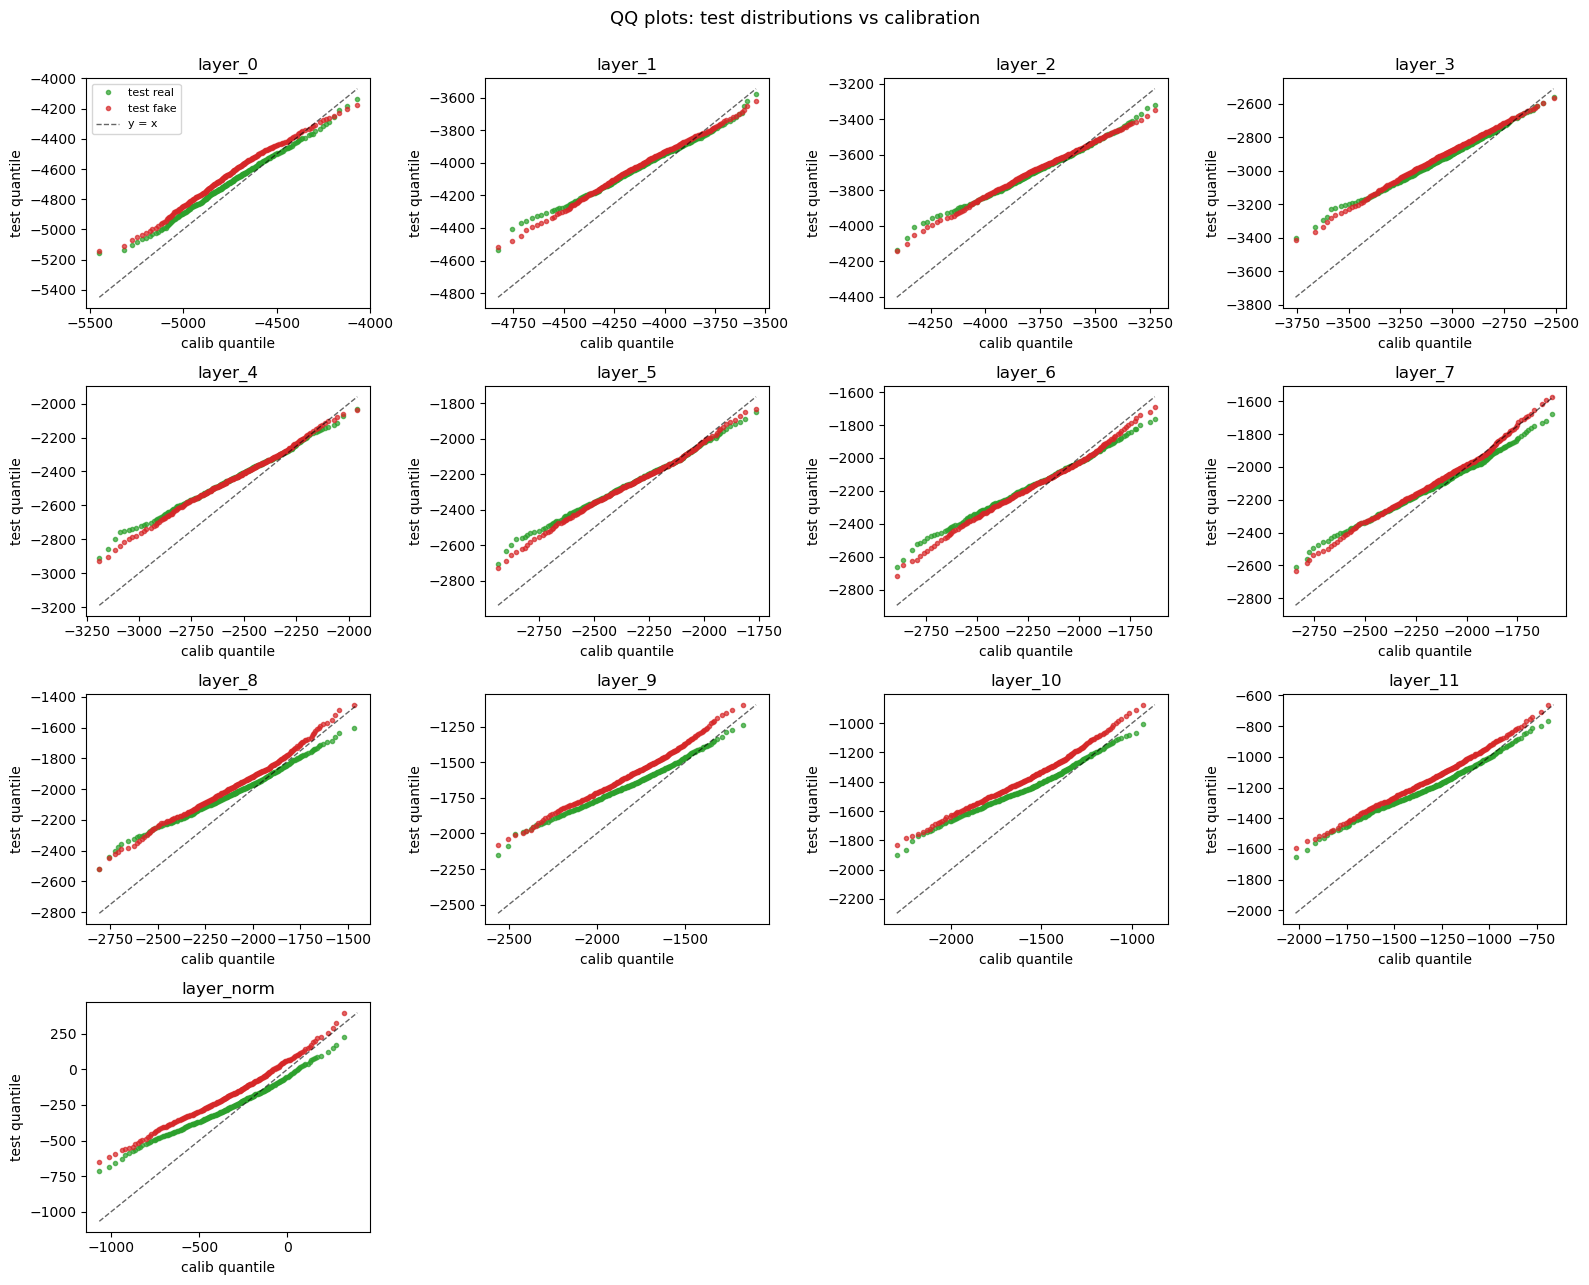

In [ ]:
"""
Compare per-layer score distributions across:
  - calibration set (real, used to fit Mahalanobis)
  - test set, real images
  - test set, fake images

Saves three figures:
  - layer_histograms.png  — overlaid histograms (KDE-smoothed)
  - layer_boxplots.png    — boxplots side by side per layer
  - layer_qq_calib_vs_test.png  — QQ plots: test-real and test-fake vs calibration
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# ---------- Load ----------

FEATURE_COLS = [f"layer_{i}" for i in range(12)] + ["layer_norm"]

X_calib = calib_df[FEATURE_COLS].to_numpy()
X_test_real = test_df.loc[test_df["label"] == 0, FEATURE_COLS].to_numpy()
X_test_fake = test_df.loc[test_df["label"] == 1, FEATURE_COLS].to_numpy()

print(f"calibration:  n={len(X_calib)}")
print(f"test real:    n={len(X_test_real)}")
print(f"test fake:    n={len(X_test_fake)}")

p = len(FEATURE_COLS)
ncols = 4
nrows = int(np.ceil(p / ncols))

# Consistent colors across all plots
C_CAL = "#1f77b4"   # blue
C_REAL = "#2ca02c"  # green
C_FAKE = "#d62728"  # red


# ---------- 1. Overlaid histograms ----------
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3 * nrows))
for i, col in enumerate(FEATURE_COLS):
    ax = axes.flat[i]
    # Common bin edges so the three histograms are comparable
    all_vals = np.concatenate([X_calib[:, i], X_test_real[:, i], X_test_fake[:, i]])
    bins = np.linspace(all_vals.min(), all_vals.max(), 50)

    ax.hist(X_calib[:, i],     bins=bins, density=True, alpha=0.45,
            color=C_CAL,  label=f"calib (n={len(X_calib)})")
    ax.hist(X_test_real[:, i], bins=bins, density=True, alpha=0.45,
            color=C_REAL, label=f"test real (n={len(X_test_real)})")
    ax.hist(X_test_fake[:, i], bins=bins, density=True, alpha=0.45,
            color=C_FAKE, label=f"test fake (n={len(X_test_fake)})")
    ax.set_title(col)
    if i == 0:
        ax.legend(fontsize=8)
for j in range(p, nrows * ncols):
    axes.flat[j].axis("off")
plt.suptitle("Per-layer score distributions", y=1.00, fontsize=13)
plt.tight_layout()
plt.savefig("layer_histograms.png", dpi=110, bbox_inches="tight")
print("Saved: layer_histograms.png")


# ---------- 2. KDE overlay (smoother view of the same thing) ----------
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3 * nrows))
for i, col in enumerate(FEATURE_COLS):
    ax = axes.flat[i]
    all_vals = np.concatenate([X_calib[:, i], X_test_real[:, i], X_test_fake[:, i]])
    xs = np.linspace(all_vals.min(), all_vals.max(), 300)

    for data, color, lbl in [(X_calib[:, i],     C_CAL,  "calib"),
                             (X_test_real[:, i], C_REAL, "test real"),
                             (X_test_fake[:, i], C_FAKE, "test fake")]:
        kde = stats.gaussian_kde(data)
        ax.plot(xs, kde(xs), color=color, lw=2, label=lbl)
        ax.fill_between(xs, kde(xs), alpha=0.15, color=color)
    ax.set_title(col)
    if i == 0:
        ax.legend(fontsize=8)
for j in range(p, nrows * ncols):
    axes.flat[j].axis("off")
plt.suptitle("Per-layer score distributions (KDE)", y=1.00, fontsize=13)
plt.tight_layout()
plt.savefig("layer_kde.png", dpi=110, bbox_inches="tight")
print("Saved: layer_kde.png")


# ---------- 3. Boxplots ----------
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
for i, col in enumerate(FEATURE_COLS):
    ax = axes.flat[i]
    bp = ax.boxplot(
        [X_calib[:, i], X_test_real[:, i], X_test_fake[:, i]],
        labels=["calib", "test\nreal", "test\nfake"],
        patch_artist=True,
        showfliers=True,
        flierprops=dict(marker=".", markersize=3, alpha=0.4),
    )
    for patch, color in zip(bp["boxes"], [C_CAL, C_REAL, C_FAKE]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(col)
    ax.grid(axis="y", alpha=0.3)
for j in range(p, nrows * ncols):
    axes.flat[j].axis("off")
plt.suptitle("Per-layer score distributions — boxplots", y=1.00, fontsize=13)
plt.tight_layout()
plt.savefig("layer_boxplots.png", dpi=110, bbox_inches="tight")
print("Saved: layer_boxplots.png")


# ---------- 4. QQ plots: test-real and test-fake vs calibration ----------
# Diagonal line = same distribution as calibration; deviations show distribution shift.
def qq_against_reference(data, reference):
    qs = np.linspace(0.005, 0.995, 200)
    return np.quantile(reference, qs), np.quantile(data, qs)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
for i, col in enumerate(FEATURE_COLS):
    ax = axes.flat[i]
    ref = X_calib[:, i]

    rx, ry = qq_against_reference(X_test_real[:, i], ref)
    fx, fy = qq_against_reference(X_test_fake[:, i], ref)

    ax.plot(rx, ry, "o", color=C_REAL, ms=3, alpha=0.7, label="test real")
    ax.plot(fx, fy, "o", color=C_FAKE, ms=3, alpha=0.7, label="test fake")
    lo = min(rx.min(), fx.min(), ry.min(), fy.min())
    hi = max(rx.max(), fx.max(), ry.max(), fy.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6, label="y = x")
    ax.set_xlabel("calib quantile")
    ax.set_ylabel("test quantile")
    ax.set_title(col)
    if i == 0:
        ax.legend(fontsize=8)
for j in range(p, nrows * ncols):
    axes.flat[j].axis("off")
plt.suptitle("QQ plots: test distributions vs calibration", y=1.00, fontsize=13)
plt.tight_layout()
plt.savefig("layer_qq_calib_vs_test.png", dpi=110, bbox_inches="tight")
print("Saved: layer_qq_calib_vs_test.png")


# ---------- 5. Per-layer summary table ----------
print("\n" + "=" * 88)
print("Per-layer summary (mean ± std) and KS distance from calibration")
print("=" * 88)
print(f"{'feature':<12s} {'calib':>20s} {'test real':>20s} {'test fake':>20s} "
      f"{'KS_real':>9s} {'KS_fake':>9s}")
print("-" * 88)
for i, col in enumerate(FEATURE_COLS):
    c = X_calib[:, i]; r = X_test_real[:, i]; f = X_test_fake[:, i]
    ks_r = stats.ks_2samp(c, r).statistic
    ks_f = stats.ks_2samp(c, f).statistic
    print(f"{col:<12s} "
          f"{c.mean():>10.1f} ± {c.std():>6.1f} "
          f"{r.mean():>10.1f} ± {r.std():>6.1f} "
          f"{f.mean():>10.1f} ± {f.std():>6.1f} "
          f"{ks_r:>9.3f} {ks_f:>9.3f}")
print("\nKS distance: 0 = identical distributions, 1 = no overlap.")
print("If KS_fake >> KS_real, that layer carries useful signal for detection.")

In [ ]:
cal.head()

,label,layer_0,layer_1,layer_2,layer_3,layer_4,layer_5,layer_6,layer_7,layer_8,layer_9,layer_10,layer_11,layer_norm,img_path
0,0.0,-4866.088867,-4343.687500,-3963.340088,-3331.582031,-2854.990967,-2638.796387,-2606.065186,-2564.922119,-2525.388184,-2215.482178,-1924.460693,-1495.806030,-554.873291,0_real__0582_class267.png
1,0.0,-4680.470703,-4044.568115,-3677.372803,-3013.973633,-2491.891357,-2287.650391,-2151.492676,-2078.778809,-2061.917725,-1738.119873,-1506.524414,-1258.801147,-185.238907,0_real__1138_class547.png
2,0.0,-4420.366211,-3783.261719,-3502.515869,-2946.027344,-2492.925049,-2258.468750,-2066.753662,-1932.673462,-1862.460938,-1518.259521,-1317.209473,-1071.634155,-84.353500,0_real__0446_class117.png
3,0.0,-4784.560547,-4069.012207,-3587.727295,-2843.331055,-2319.605225,-2089.756348,-1911.081665,-1840.943970,-1851.870483,-1603.479736,-1356.930176,-1134.509766,-119.831734,0_real__1202_class23.png
4,0.0,-4838.865234,-4077.283936,-3642.882568,-2931.245605,-2394.621338,-2185.959717,-2092.115967,-2021.816162,-1924.525513,-1714.521240,-1483.040771,-1218.552490,-271.177765,0_real__0470_class13.png


In [ ]:
cal.columns

Index(['label', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4',
       'layer_5', 'layer_6', 'layer_7', 'layer_8', 'layer_9', 'layer_10',
       'layer_11', 'layer_norm', 'img_path'],
      dtype='object')

In [ ]:
test.columns

Index(['label', 'layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4',
       'layer_5', 'layer_6', 'layer_7', 'layer_8', 'layer_9', 'layer_10',
       'layer_11', 'layer_norm', 'img_path'],
      dtype='object')

In [ ]:
real_scores = cal[['layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4',
       'layer_5', 'layer_6', 'layer_7', 'layer_8', 'layer_9', 'layer_10',
       'layer_11', 'layer_norm']].to_numpy()

test_scores = test[['layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4',
       'layer_5', 'layer_6', 'layer_7', 'layer_8', 'layer_9', 'layer_10',
       'layer_11', 'layer_norm']].to_numpy()

In [ ]:
# Fit on real images only
# MinCovDet is robust if your calibration set might contain a few bad samples;
# EmpiricalCovariance is fine if you trust the calibration set is clean
estimator = MinCovDet().fit(real_scores)

# Squared Mahalanobis distances
test_md2 = estimator.mahalanobis(test_scores)

# Threshold options (try both, see which fits your data)
threshold_chi2 = chi2.ppf(0.975, df=12)               # parametric
cal_md2 = estimator.mahalanobis(real_scores)
threshold_emp = np.quantile(cal_md2, 0.975)            # empirical

is_fake = test_md2 > threshold_emp